# Classer les vulnérabilités par leur type - CVE -> CWE

### Certification Alyra - Sujet 2 : *transfer learning et fine-tuning*

---

Une **CVE** est une vulnérabilité publiée, décrite en texte libre par son découvreur.
Un **CWE** est son *type* : injection SQL, débordement de tampon, autorisation manquante...
Notre tâche : **lire la description, prédire le type**.

Environ 40 000 CVE sont publiées chaque année. Les étiqueter à la main est un travail d'expert.
D'où la question : **un modèle de langage pré-entraîné, spécialisé par fine-tuning, peut-il le faire ?**

---

## Les chiffres à retenir

| | |
|---|---|
| **0,467** | macro-F1 en test sur 71 classes - contre **0,424** pour une régression logistique sur TF-IDF |
| **96,9 % -> 39,8 %** | l'exactitude en laboratoire de notre config la plus exacte (10 classes), et sa précision réelle en production - l'écart est le coeur du travail |
| **12 pistes testées** | dix sans gain, une qui aide modestement, une qui change la donne |
| **+11 et +31 points** | ce que gagne la douzième - précision **et** couverture - en changeant la granularité de la cible |

Le deuxième chiffre est le coeur de ce travail : l'évaluation standard peut classer les modèles à
l'envers. Le quatrième en est la conclusion - après onze tentatives d'améliorer le *modèle*, celle
qui rapporte le plus consiste à **changer la question posée**.

> Ce notebook contient aussi **une erreur que nous avons commise et corrigée** : notre premier
> bilan des onze pistes utilisait le protocole d'évaluation que nous dénonçons par ailleurs.
> La section 8 la raconte, parce que c'en est la meilleure démonstration.

---

## Comment lire ce notebook

Ce notebook suit l'ordre de **l'argument**, pas celui du pipeline :

> **la question** -> **la réponse naïve** (97 % d'exactitude) -> **pourquoi elle est fausse**
> -> **la réponse honnête** -> **ce qu'on a essayé qui n'a pas marché**

Il **ne réentraîne rien** : il relit les résultats produits par le notebook technique
`07_cwe_finetuning.ipynb`, qui contient le code d'entraînement exécuté sur GPU. Ici, tous les
chiffres affichés sont **lus depuis `runs/*.json`** - aucun n'est écrit en dur.

**Plan (13 sections) :** 0 - Chargement - 1 - La question - 2 - Le périmètre (pourquoi 71 classes)
- 3 - Le découpage temporel - 4 - Transfer learning & fine-tuning - 5 - La réponse naïve (97 %)
- 6 - Pourquoi elle est fausse - 7 - La réponse honnête (le contrat) - 8 - Onze pistes + un bilan
refait - 9 - La douzième piste (changer la question) - 10 - Où le modèle se trompe
- 11 - Démonstration en direct - 12 - Conclusion.

> **Repère de lecture** : sauf mention contraire, les **contrats** cités concernent le **modèle
> déployé (entraîné sur 218k CVE)** ; les **ablations** comparent la configuration de **référence
> (40k CVE)**, à budget constant.

> ⏱️ Temps d'exécution complet : quelques secondes (sections 1 à 9), plus ~30 s pour la
> démonstration finale qui charge réellement le modèle.

---
# 0 - Chargement des artefacts

Rien de conceptuel ici : on prépare les outils et on inventorie ce qui est disponible sur disque.

Le point à noter est `charger()` - un accès unique et centralisé aux résultats. Chaque figure et
chaque tableau de ce notebook passe par cette fonction. Si un chiffre affiché plus bas vous semble
douteux, il vient d'un fichier JSON qu'on peut ouvrir et vérifier.

In [1]:
import json                      # les resultats d'experience sont stockes en JSON
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

RUNS = Path("runs")            # un fichier JSON par experience
DATA = Path("data")            # les splits train/val/test, au format parquet

# --- Charte graphique --------------------------------------------------------
# Une seule palette pour tout le notebook : la couleur porte du SENS, pas de la decoration.
BLEU   = "#2c6fbb"   # notre modele, la configuration retenue
ORANGE = "#e8833a"   # les references : TF-IDF, vote majoritaire, autres configurations
ROUGE  = "#c0392b"   # la production, l'echec, ce qui degrade
VERT   = "#2a9d5c"   # ce qui ameliore
GRIS   = "#8a94a0"   # le contexte, les elements secondaires

plt.rcParams.update({
    "figure.figsize":   (11, 4.6),   # format large : lisible une fois projete
    "figure.dpi":       110,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.spines.top":   False,      # on retire les bordures inutiles : moins d'encre, plus de donnees
    "axes.spines.right": False,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.linestyle":   "--",
})

# Formateurs reutilises : separateur de milliers, et pourcentages sur les axes.
MILLIERS = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
POURCENT = PercentFormatter(xmax=1, decimals=0)


def charger(nom: str) -> dict:
    """Lit un resultat d'experience depuis runs/<nom>.json.

    TOUS les chiffres de ce notebook transitent par ici. Aucune valeur n'est recopiee a la main :
    c'est ce qui garantit que le notebook et les fichiers de resultats ne peuvent pas diverger.
    """
    return json.loads((RUNS / f"{nom}.json").read_text())


def pct(x: float, dec: int = 1) -> str:
    """Formate une proportion en pourcentage a la francaise (virgule decimale)."""
    return f"{x * 100:.{dec}f} %".replace(".", ",")


def milliers(n) -> str:
    """Formate un entier avec l'espace comme separateur de milliers.

    Volontairement une fonction, et non un .replace() applique a la phrase entiere :
    en francais le separateur decimal est aussi une virgule, et remplacer toutes les
    virgules d'une chaine transforme "90,0 %" en "90 0 %".
    """
    return f"{int(n):,}".replace(",", " ")


# --- Inventaire de ce qui est disponible -------------------------------------
experiences = sorted(p.stem for p in RUNS.glob("*.json"))
print(f"{len(experiences)} resultats d'experience disponibles dans runs/")
print(f"{len(list(Path('.').glob('training_log_*.csv')))} journaux d'entrainement (une ligne par epoque)")
print(f"{len(list(Path('.').glob('*.weights.h5')))} jeux de poids de modele sauvegardes")

48 resultats d'experience disponibles dans runs/
10 journaux d'entrainement (une ligne par epoque)
11 jeux de poids de modele sauvegardes


---
---
# 1 - La question

## Ce qu'on cherche à faire

Chaque CVE publiée arrive avec une description en anglais, rédigée par un humain, sans format imposé :

> *"A buffer overflow in the HTTP parser of Acme Router 3.2 allows a remote attacker to execute
> arbitrary code via a crafted Content-Length header."*

Un analyste lit ça et sait immédiatement qu'il s'agit d'un **CWE-120** (débordement de tampon).
Notre modèle doit apprendre à faire la même lecture.

## Pourquoi c'est utile

Le type de faille conditionne la réponse : un débordement mémoire et une injection SQL n'appellent
ni les mêmes correctifs, ni les mêmes contournements, ni les mêmes équipes. Une CVE non typée est
une CVE qu'on ne sait pas router.

## Pourquoi c'est difficile

Quatre obstacles, que les figures suivantes quantifient :

1. **Le nombre de types.** Le catalogue MITRE en version 4.20 définit **969 faiblesses**, réparties
   en **422 catégories** et organisées par **59 vues**. Combien en retenir comme classes ?
2. **La structure.** Ces 969 types ne forment pas une liste plate : ils sont organisés en
   **hiérarchie de spécialisation**, et certains sont des cas particuliers d'autres. La section 2
   montre pourquoi cela change complètement la nature de la tâche.
3. **Le déséquilibre.** Quelques types couvrent la moitié des CVE ; des centaines d'autres sont rares.
4. **La dérive temporelle.** Le vocabulaire des vulnérabilités change - les technologies de 2010 ne
   sont pas celles de 2025.

Commençons par regarder les données.

CVE etiquetees exploitables : 331 269
CWE distincts observes      : 788


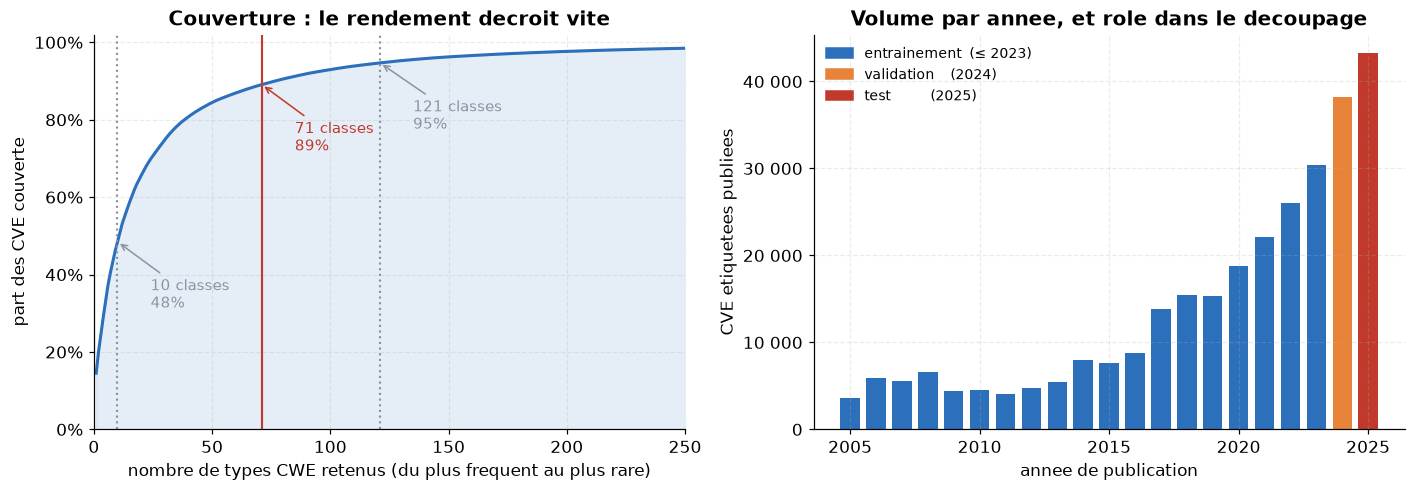

In [2]:
# La distribution complete des CWE a ete precalculee et mise en cache (runs/couverture_cwe.json)
# pour rendre ce notebook autonome : il n'a pas besoin d'acceder au jeu de donnees source.
couv = charger("couverture_cwe")

cumul  = np.array(couv["couverture_cumulee"])     # part des CVE couverte par les N CWE les plus frequents
par_an = couv["cve_par_annee"]

print(f"CVE etiquetees exploitables : {couv['n_cve_etiquetees']:,}".replace(",", " "))
print(f"CWE distincts observes      : {couv['n_cwe_distincts']:,}".replace(",", " "))

fig, (g, d) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Gauche : combien de types faut-il retenir pour couvrir quelle part des CVE ? -----------------
n = np.arange(1, len(cumul) + 1)
g.plot(n, cumul, color=BLEU, lw=2)
g.fill_between(n, cumul, alpha=0.12, color=BLEU)

# On marque les trois perimetres qu'on a reellement entraines et compares.
for taille, couleur, style in ((10, GRIS, ":"), (71, ROUGE, "-"), (121, GRIS, ":")):
    g.axvline(taille, color=couleur, ls=style, lw=1.4)
    g.annotate(f"{taille} classes\n{cumul[taille - 1]:.0%}",
               xy=(taille, cumul[taille - 1]), xytext=(taille + 14, cumul[taille - 1] - 0.17),
               fontsize=9.5, color=couleur,
               arrowprops=dict(arrowstyle="->", color=couleur, lw=1))

g.set(xlim=(0, 250), ylim=(0, 1.02),
      xlabel="nombre de types CWE retenus (du plus frequent au plus rare)",
      ylabel="part des CVE couverte")
g.yaxis.set_major_formatter(POURCENT)
g.set_title("Couverture : le rendement decroit vite")

# --- Droite : volume publie par annee -----------------------------------------------------------
annees  = sorted(int(a) for a in par_an if 2005 <= int(a) <= 2025)
volumes = [par_an[str(a)] if str(a) in par_an else par_an[a] for a in annees]

# La couleur encode le role de chaque annee dans le decoupage : c'est la figure qui explique le split.
couleurs = [BLEU if a <= 2023 else (ORANGE if a == 2024 else ROUGE) for a in annees]
d.bar(annees, volumes, color=couleurs, width=0.75)
d.set(xlabel="annee de publication", ylabel="CVE etiquetees publiees")
d.yaxis.set_major_formatter(MILLIERS)
d.set_title("Volume par annee, et role dans le decoupage")

# Legende construite a la main : les couleurs designent des roles, pas des series.
from matplotlib.patches import Patch
d.legend(handles=[Patch(color=BLEU,   label="entrainement  (≤ 2023)"),
                  Patch(color=ORANGE, label="validation    (2024)"),
                  Patch(color=ROUGE,  label="test          (2025)")],
         loc="upper left", fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

**Ce que montre la figure de gauche.** La courbe monte très vite puis s'aplatit. Les 10 types les
plus fréquents couvrent déjà près de la moitié des CVE ; il en faut 71 pour approcher 90 %, et
au-delà chaque type supplémentaire n'apporte plus qu'une fraction de point.

C'est le premier arbitrage du projet, et la section suivante le tranche avec des mesures.

**Ce que montre la figure de droite.** Le volume de publication augmente fortement - 2024 et 2025
pèsent chacune plus que la décennie 2005-2015 réunie. Les couleurs annoncent notre découpage :
on apprend sur le passé et on évalue sur l'avenir, exactement comme en production.

---
# 2 - Le périmètre : pourquoi 71 classes

Voici l'arbitrage central de la préparation des données, et une décision que le jury est en droit
de nous demander de justifier.

**L'argument pour élargir.** Plus on retient de types, plus on couvre de CVE. Avec 10 classes,
la moitié des CVE tombe hors périmètre ; avec 121, on couvre presque tout.

**L'argument pour restreindre.** Chaque type ajouté est plus rare que le précédent. Les derniers
n'ont que quelques dizaines d'exemples d'entraînement - trop peu pour être appris, et assez pour
brouiller les frontières des types voisins.

> **Ce que "71 classes" veut dire exactement** : ce sont les **70 CWE les plus fréquents**
> (>= 500 CVE chacun) **+ une 71ᵉ classe fourre-tout, `CWE-OTHER`**, qui regroupe tous les autres
> types. `CWE-OTHER` apparaîtra dans les matrices de confusion et la démo : c'est **une vraie classe
> à part entière**, pas une absence de réponse. (À ne pas confondre avec le bucket `autre` des
> 11 **familles** en section 9, qui est un fourre-tout différent, au niveau des grandes familles.)

Nous n'avons pas tranché à l'intuition : **nous avons entraîné les trois périmètres** et mesuré.

In [3]:
# Les trois perimetres ont ete entraines a l'identique (meme modele, meme budget, meme graine).
# Seul le nombre de classes change : c'est une ablation a variable unique.
PERIMETRES = [
    ("10 classes",  "distilbert-base-uncased_finetune_10cl",  10),
    ("71 classes",  "distilbert-base-uncased_finetune_71cl",  71),
    ("121 classes", "distilbert-base-uncased_finetune_121cl", 121),
]

lignes = []
for etiquette, run_id, k in PERIMETRES:
    labo    = charger(run_id)                 # metriques sur le jeu de test filtre  -> le "laboratoire"
    contrat = charger(f"contrat_{run_id}")    # metriques sur la population reelle   -> la "production"
    lignes.append({
        "perimetre":            etiquette,
        "couverture theorique": pct(cumul[k - 1], 0),          # part des CVE que le perimetre peut nommer
        "exactitude (labo)":    pct(labo["test"]["accuracy"]),
        "macro-F1 (labo)":      f"{labo['test']['f1_macro']:.3f}".replace(".", ","),
        # courbe[0] = aucun seuil de confiance : le modele repond a tout, sur la population reelle.
        # C'est la mesure qui discrimine vraiment les trois perimetres.
        "precision sans seuil (prod.)": pct(contrat["courbe"][0]["precision"]),
        "CVE nommees a 90 % de prec.": milliers(contrat["contrat"]["n_cve"]),
    })

print("Les trois perimetres, en laboratoire ET en production\n")
print(pd.DataFrame(lignes).to_string(index=False))

Les trois perimetres, en laboratoire ET en production

  perimetre couverture theorique exactitude (labo) macro-F1 (labo) precision sans seuil (prod.) CVE nommees a 90 % de prec.
 10 classes                 48 %            96,9 %           0,947                       39,8 %                         205
 71 classes                 89 %            59,7 %           0,467                       59,5 %                      15 476
121 classes                 95 %            57,7 %           0,414                       58,2 %                       5 245


Ce tableau contient déjà le résultat le plus important du projet, mais il est encore illisible :
la colonne "exactitude" et la colonne "précision réelle" ne racontent pas la même histoire.
Nous y reviendrons en **section 6** - c'est là que l'écart s'explique.

Pour l'instant, retenons la conclusion de l'arbitrage :

> **71 classes couvrent 89 % des CVE.** Passer à 121 ajoute 5,6 points de couverture théorique -
> et fait chuter le nombre de CVE réellement nommées avec fiabilité. Le périmètre le plus large
> n'est pas le plus utile.

## La taxonomie n'est pas une liste : c'est un graphe de spécialisation

Voici le point que nous avons compris trop tard, et qui éclaire une grande partie de nos résultats.

Les 969 faiblesses du catalogue MITRE sont organisées en **niveaux d'abstraction**, du plus général
au plus précis :

| Niveau | Rôle | Exemple |
|---|---|---|
| `Pillar` | les grandes familles, la racine | CWE-707 - *Improper Neutralization* |
| `Class` | un mécanisme, indépendant de la technologie | CWE-74 - *Injection* |
| `Base` | une faille concrète et nommable | CWE-89 - *Injection SQL* |
| `Variant` | liée à une technologie précise | CWE-98 - *inclusion de fichier PHP* |

Ces niveaux sont reliés par des relations **ChildOf** : CWE-89 est un cas particulier de CWE-74,
lui-même un cas particulier de CWE-707.

**Et ce n'est même pas un arbre.** Un noeud peut avoir plusieurs parents - CWE-78 (*injection de
commande OS*) descend à la fois de CWE-77 (*injection de commande*) et de CWE-74 (*injection*).
La structure exacte est un **graphe orienté acyclique**.

In [4]:
# Structure de la taxonomie, precalculee depuis le XML officiel MITRE (runs/taxonomie_cwe.json)
# pour que ce notebook reste autonome. Le catalogue brut pese 18 Mo.
taxo = charger("taxonomie_cwe")

print(f"Catalogue MITRE version {taxo['version_catalogue']}\n")
print(f"  faiblesses (Weakness)                : {taxo['n_faiblesses']:>6}")
print(f"  categories (regroupements du NVD)    : {taxo['n_categories']:>6}")
print(f"  vues (points de vue thematiques)     : {taxo['n_vues']:>6}")
print(f"  relations 'est un cas particulier de': {taxo['n_relations_childof']:>6}")
print(f"  noeuds ayant PLUSIEURS parents       : {taxo['n_noeuds_multi_parents']:>6}"
      f"   -> graphe, pas arbre\n")

# Comparaison de la composition : le catalogue entier, puis NOS classes.
print(f"{'niveau':<12}{'catalogue':>12}{'nos classes':>14}")
print("-" * 38)
for niv in ("Pillar", "Class", "Base", "Variant", "Compound", "Category"):
    print(f"{niv:<12}{taxo['abstraction_catalogue'].get(niv, '-'):>12}"
          f"{taxo['abstraction_nos_classes'].get(niv, '-'):>14}")

Catalogue MITRE version 4.20

  faiblesses (Weakness)                :    969
  categories (regroupements du NVD)    :    422
  vues (points de vue thematiques)     :     59
  relations 'est un cas particulier de':   1318
  noeuds ayant PLUSIEURS parents       :    200   -> graphe, pas arbre

niveau         catalogue   nos classes
--------------------------------------
Pillar                10             1
Class                114            18
Base                 539            39
Variant              299             6
Compound               7             1
Category               -             5


**Nos classes ne sont pas au même niveau de l'arbre.** Elles s'étalent du `Pillar` le plus général
au `Variant` le plus spécifique. Ce n'est pas une négligence de notre part : nous avons retenu les
types **les plus fréquents dans les données**, et le NVD étiquette lui-même à des niveaux
hétérogènes selon l'analyste et l'année.

Regardons ce que cela donne concrètement sur une seule famille.

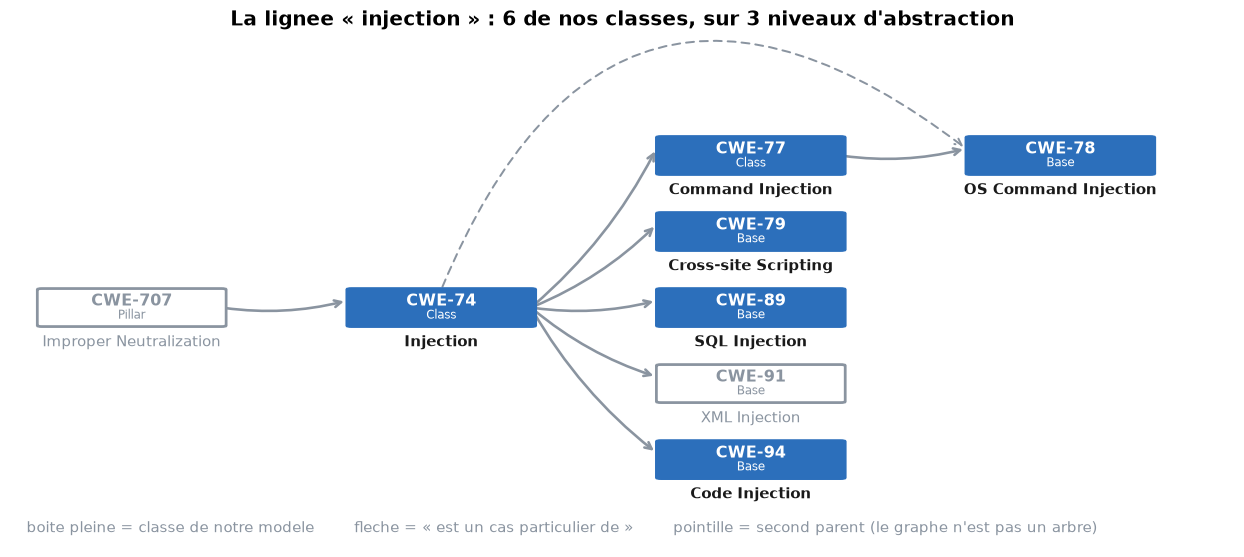

Paires parent -> enfant dont LES DEUX sont des classes de notre modele : 47
   CWE-119 -> CWE-120
   CWE-119 -> CWE-125
   CWE-119 -> CWE-787
   CWE-20 -> CWE-119
   CWE-20 -> CWE-120
   CWE-20 -> CWE-134
   ... et 41 autres


In [5]:
import re
from matplotlib.patches import FancyBboxPatch

famille = {n["cwe"]: n for n in taxo["famille_injection"]}

def nom_court(intitule: str) -> str:
    """Extrait le nom usuel d'un CWE.

    Les intitules officiels sont longs et se ressemblent tous ("Improper Neutralization of
    Special Elements used in..."). MITRE place le nom usuel entre parentheses et apostrophes
    a la fin -- c'est celui que tout le monde emploie, et le seul lisible sur une figure.
    """
    if m := re.search(r"\('([^']+)'\)", intitule):
        return m.group(1)
    return intitule.split(" (aka")[0]

# La lignee "injection" : 6 de nos classes y cohabitent, sur 3 niveaux d'abstraction.
# CWE-98 n'y figure PAS : ses parents reels sont CWE-706 et CWE-829, pas CWE-94.
pos = {"CWE-707": (0, 2.2), "CWE-74": (1, 2.2),
       "CWE-77": (2, 4.4), "CWE-79": (2, 3.3), "CWE-89": (2, 2.2),
       "CWE-91": (2, 1.1), "CWE-94": (2, 0.0),
       "CWE-78": (3, 4.4)}
L, H = 0.58, 0.52     # largeur et hauteur des boites

fig, ax = plt.subplots(figsize=(12, 5.2))

# Les aretes d'abord, pour qu'elles passent SOUS les boites.
for cwe, (x2, y2) in pos.items():
    for p in famille[cwe]["parents"]:
        if p not in pos:
            continue
        x1, y1 = pos[p]
        # CWE-78 descend de CWE-77 ET de CWE-74 : on distingue le second lien en pointille.
        # Courbure forte pour le second lien : il doit passer AU-DESSUS des autres boites,
        # sinon il frole CWE-89 et donne l'impression de le designer.
        second = cwe == "CWE-78" and p == "CWE-74"
        ax.annotate("", xy=(x2 - 0.015, y2 + 0.1),
                    xytext=(x1 + L / 2, y1 + H / 2) if second else (x1 + L, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.3 if second else 1.7, color=GRIS,
                                    ls=(0, (4, 3)) if second else "-",
                                    connectionstyle=f"arc3,rad={-0.65 if second else 0.1}"))

for cwe, (x, y) in pos.items():
    info = famille[cwe]
    a_nous = info["dans_nos_classes"]
    ax.add_patch(FancyBboxPatch((x, y - H / 2), L, H, boxstyle="round,pad=0.015",
                                facecolor=BLEU if a_nous else "white",
                                edgecolor=BLEU if a_nous else GRIS, lw=1.8, zorder=3))
    ax.text(x + L / 2, y + 0.09, cwe, ha="center", va="center", fontsize=10.5,
            fontweight="bold", color="white" if a_nous else GRIS, zorder=4)
    ax.text(x + L / 2, y - 0.11, info["abstraction"], ha="center", va="center", fontsize=8,
            color="white" if a_nous else GRIS, zorder=4)
    # Nom usuel SOUS la boite : a droite il chevaucherait la colonne suivante.
    ax.text(x + L / 2, y - H / 2 - 0.14, nom_court(info["nom"]), ha="center", va="top",
            fontsize=9.5, color="#1a1a1a" if a_nous else GRIS,
            fontweight="bold" if a_nous else "normal")

ax.set(xlim=(-0.1, 3.85), ylim=(-1.25, 6.15))
ax.axis("off")
ax.set_title("La lignee « injection » : 6 de nos classes, sur 3 niveaux d'abstraction",
             fontsize=13, fontweight="bold")
# Legende en BAS : l'arete pointillee occupe tout le haut de la figure.
ax.text(-0.05, -1.05, "boite pleine = classe de notre modele        "
                      "fleche = « est un cas particulier de »        "
                      "pointille = second parent (le graphe n'est pas un arbre)",
        fontsize=9.5, color=GRIS)

plt.tight_layout()
plt.show()

print(f"Paires parent -> enfant dont LES DEUX sont des classes de notre modele : "
      f"{len(taxo['paires_parent_enfant_dans_nos_classes'])}")
for p in taxo["paires_parent_enfant_dans_nos_classes"][:6]:
    print(f"   {p}")
print(f"   ... et {len(taxo['paires_parent_enfant_dans_nos_classes']) - 6} autres")

## La conséquence, et elle est lourde

> **47 paires de nos propres étiquettes sont en relation directe parent -> enfant.**

Notre tâche n'est donc *pas* une classification à 71 catégories disjointes. C'est un choix parmi
des étiquettes qui, par définition MITRE, **se contiennent les unes les autres**. Quand le modèle
doit trancher entre CWE-74 (*injection*) et CWE-89 (*injection SQL*) pour une CVE qui décrit une
injection SQL, **les deux réponses sont correctes** - seule l'une est celle qu'a choisie
l'annotateur.

Cela a trois conséquences que nous vérifierons plus loin :

1. **Une partie de notre "taux d'erreur" est structurelle**, pas apprenable. La section 10 la
   quantifie : la moitié de nos erreurs se produit exactement sur ces paires imbriquées.
2. **Le macro-F1 pénalise le modèle pour une ambiguïté qu'il n'a pas créée.**
3. Cela suggère d'exploiter la hiérarchie plutôt que de traiter les 71 classes comme une liste
   plate. Nous l'avons fait de **deux manières opposées**, avec deux résultats opposés :
   remonter aux ancêtres à profondeur variable a été **réfuté** (section 8), tandis que
   redéfinir la cible sur une partition grossière fixe est **la seule piste qui aboutit**
   (section 9).

## Le déséquilibre des classes

Une fois le périmètre fixé, un troisième problème apparaît.

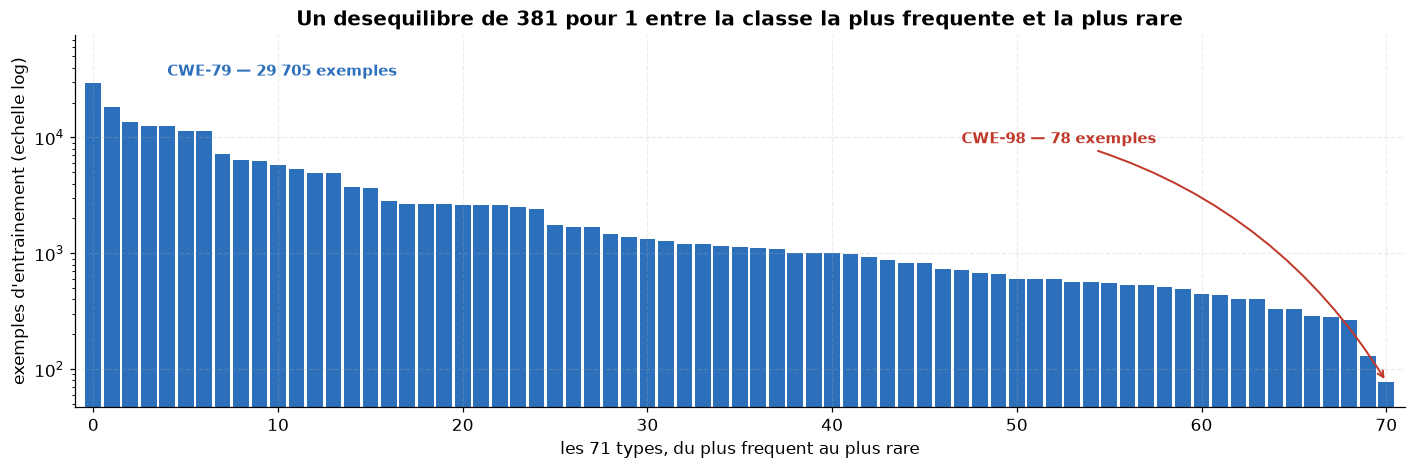

classe la plus frequente : CWE-79        29 705 exemples
classe la plus rare      : CWE-98            78 exemples
rapport                  : 381 pour 1


In [6]:
# On lit le jeu d'entrainement reel : c'est lui qui determine ce que le modele peut apprendre.
train = pd.read_parquet(DATA / "cwe71" / "train.parquet")
effectifs = train.label_name.value_counts()
ratio = effectifs.iloc[0] / effectifs.iloc[-1]     # calcule avant le trace : il sert dans le titre

fig, ax = plt.subplots(figsize=(13, 4.4))

# Echelle logarithmique en ordonnee : sans elle, les 60 classes rares sont ecrasees a zero
# et la figure ne montre plus rien du probleme qu'elle est censee illustrer.
ax.bar(range(len(effectifs)), effectifs.values, color=BLEU, width=0.85)
ax.set_yscale("log")
ax.set(xlabel="les 71 types, du plus frequent au plus rare",
       ylabel="exemples d'entrainement (echelle log)",
       xlim=(-1, len(effectifs)))
ax.set_title(f"Un desequilibre de {ratio:.0f} pour 1 entre la classe la plus frequente et la plus rare")

# On annote les deux extremes : ce sont eux qui donnent l'echelle du probleme.
# Les deux textes sont places DANS l'espace vide au-dessus des barres, jamais par-dessus.
ax.annotate(f"{effectifs.index[0]} — {milliers(effectifs.iloc[0])} exemples",
            xy=(0, effectifs.iloc[0]), xytext=(4, effectifs.iloc[0] * 1.15),
            fontsize=10, color=BLEU, fontweight="bold")
ax.annotate(f"{effectifs.index[-1]} — {effectifs.iloc[-1]} exemples",
            xy=(len(effectifs) - 1, effectifs.iloc[-1]),
            xytext=(len(effectifs) - 24, effectifs.iloc[0] * 0.30),
            fontsize=10, color=ROUGE, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ROUGE, lw=1.3,
                            connectionstyle="arc3,rad=-0.2"))
ax.set_ylim(effectifs.iloc[-1] * 0.6, effectifs.iloc[0] * 2.6)

plt.tight_layout()
plt.show()

print(f"classe la plus frequente : {effectifs.index[0]:<12} {milliers(effectifs.iloc[0]):>7} exemples")
print(f"classe la plus rare      : {effectifs.index[-1]:<12} {milliers(effectifs.iloc[-1]):>7} exemples")
print(f"rapport                  : {ratio:.0f} pour 1")

**Pourquoi c'est un problème.** Un modèle optimisé sur la fonction de coût par défaut apprend qu'il
peut faire baisser son erreur en ignorant purement et simplement les classes rares : elles pèsent
si peu dans le total que les négliger coûte presque rien.

**Notre réponse : la pondération des classes.** Chaque exemple reçoit un poids inversement
proportionnel à la fréquence de sa classe - une erreur sur une classe rare coûte plus cher.

**Avec un plafond, et c'est un choix délibéré.** Le rapport brut des effectifs, affiché ci-dessus,
dépasse 300 pour 1. Appliqué tel quel comme poids, il rendrait la mise à jour instable : quelques
exemples rares domineraient chaque lot. Nous plafonnons donc les poids, ce qui échange un peu de
rappel sur les classes très rares contre un entraînement qui converge.

**Et une métrique qui rend le problème visible.** L'exactitude est dominée par les classes
fréquentes et masquerait complètement l'échec sur les rares. Nous pilotons donc l'entraînement sur
le **macro-F1**, qui donne le même poids à chaque classe quelle que soit sa taille. Un modèle qui
abandonne les classes rares le paie immédiatement sur cette métrique.

In [7]:
cfg = charger("distilbert-base-uncased_finetune_71cl")["config"]

# Le plafond de ponderation est un hyperparametre du projet, enregistre avec chaque experience.
print(f"rapport brut des effectifs        : {ratio:>6.0f} pour 1")
print(f"plafond applique aux poids        : {cfg['class_weight_max']:>6.0f} pour 1")
print(f"metrique de pilotage              : macro-F1 (poids egal a chaque classe)")

rapport brut des effectifs        :    381 pour 1
plafond applique aux poids        :     10 pour 1
metrique de pilotage              : macro-F1 (poids egal a chaque classe)


---
# 3 - Le découpage : temporel, pas aléatoire

C'est un choix méthodologique dont les conséquences sont importantes, et qu'il faut assumer :
**il dégrade nos chiffres**. Nous l'avons retenu quand même.

## Ce que fait un découpage aléatoire

Le réflexe habituel est de mélanger toutes les CVE et d'en tirer 20 % pour le test. C'est
inadapté ici, pour une raison précise : **les CVE arrivent par grappes**. Une même campagne de
recherche publie souvent des dizaines de vulnérabilités quasi identiques, dans le même produit,
décrites dans les mêmes termes, à quelques jours d'intervalle.

Un tirage aléatoire éclate ces grappes entre l'entraînement et le test. Le modèle a alors vu, à
l'entraînement, des quasi-jumelles des CVE sur lesquelles on l'évalue. Le score obtenu ne mesure
plus sa capacité à généraliser, mais sa capacité à reconnaître ce qu'il a déjà lu. **C'est une
fuite de données**, et elle est invisible : rien dans le protocole ne signale l'anomalie.

## Ce que nous faisons

Une coupure sur le temps, sans recouvrement possible :

| Rôle | Période | Sert à |
|---|---|---|
| **Entraînement** | <= 2023 | apprendre |
| **Validation** | 2024 | choisir l'époque, calibrer le seuil |
| **Test** | 2025 | mesurer, une seule fois |

Aucune CVE de 2025 n'a pu influencer quoi que ce soit. C'est exactement la situation de production :
un modèle entraîné aujourd'hui sera appliqué demain, à des vulnérabilités qui n'existent pas encore.

**Le coût est réel.** Nos scores sont plus bas qu'ils ne le seraient avec un découpage aléatoire,
parce qu'ils intègrent la dérive du vocabulaire entre 2023 et 2025. Nous préférons un chiffre
plus bas et vrai à un chiffre plus haut et trompeur.

In [8]:
# Verification que le decoupage est bien etanche : aucune annee ne doit apparaitre dans deux splits.
splits = {nom: pd.read_parquet(DATA / "cwe71" / f"{nom}.parquet") for nom in ("train", "val", "test")}

print(f"{'split':<14}{'CVE':>10}   annees couvertes")
for nom, df in splits.items():
    print(f"{nom:<14}{len(df):>10,}   {df.year.min()} - {df.year.max()}".replace(",", " "))

# Un split est etanche si l'intersection des ensembles d'annees est vide, deux a deux.
ens = {nom: set(df.year.unique()) for nom, df in splits.items()}
chevauchements = sum(len(ens[a] & ens[b]) for a, b in (("train", "val"), ("train", "test"), ("val", "test")))
print(f"\nannees partagees entre deux splits : {chevauchements}   ->  "
      f"{'aucune fuite temporelle possible' if chevauchements == 0 else 'ATTENTION : fuite'}")

split                CVE   annees couvertes
train            217 966   2000 - 2023
val               38 223   2024 - 2024
test              43 229   2025 - 2025

annees partagees entre deux splits : 0   ->  aucune fuite temporelle possible


---
---
# 4 - La méthode : transfer learning et fine-tuning

C'est le coeur du sujet Alyra. Expliquons précisément ce qu'on réutilise et ce qu'on ajoute.

## Le problème que le transfer learning résout

Notre jeu d'entraînement contient environ 40 000 descriptions. C'est très peu pour apprendre
l'anglais - il en faudrait des milliards de mots. Un modèle entraîné de zéro sur ce volume devrait
découvrir simultanément la grammaire, le vocabulaire, **et** la tâche de classification. Il échouerait
sur les trois.

Le transfer learning découpe ce problème en deux :

1. **Quelqu'un d'autre a déjà appris l'anglais.** DistilBERT a été pré-entraîné sur Wikipedia et
   BookCorpus. Il sait déjà que "overflow" et "débordement" relèvent du même champ, que
   "attacker" est un agent, que "crafted" qualifie une entrée malveillante.
2. **Nous n'apprenons que la tâche.** Traduire cette compréhension en un choix parmi 71 types.

## Notre architecture

```
   description de la CVE (texte brut)
              │
              ▼
   ┌──────────────────────────────┐
   │  Tokenizer                   │   découpe en sous-mots, tronque/complète à 192 jetons
   └──────────────────────────────┘
              │
              ▼
   ┌──────────────────────────────┐
   │  DistilBERT pré-entraîné     │   ~66 M paramètres - RÉUTILISÉS, pas réappris
   │  6 couches Transformer       │
   └──────────────────────────────┘
              │
              ▼   on ne garde que le vecteur du jeton [CLS],
                  qui agrège le sens de toute la description
   ┌──────────────────────────────┐
   │  Dropout(0,3)                │   régularisation : le seul rempart contre le surapprentissage
   └──────────────────────────────┘
              │
              ▼
   ┌──────────────────────────────┐
   │  Dense(71, softmax, float32) │   la TÊTE - ajoutée par nous, apprise de zéro
   └──────────────────────────────┘
              │
              ▼
      une probabilité par type de faille
```

## Deux détails d'implémentation qui ont coûté du temps

Ils méritent d'être signalés, parce qu'ils échouent de façon peu lisible :

**`dtype='float32'` sur la couche de sortie.** L'entraînement tourne en précision mixte
(`mixed_float16`) pour tenir dans 6 Go de mémoire GPU. Mais le softmax en demi-précision produit des
dépassements de capacité dès que les logits s'écartent un peu - la perte devient `NaN` sans message
d'erreur. Forcer la sortie en float32 corrige le problème sans annuler le gain mémoire, qui vient
des couches internes.

**`padding='max_length'`, surtout pas `padding=True`.** Avec `padding=True`, le tokenizer complète
chaque lot à la longueur de son plus long élément - donc à une longueur *variable*. Or notre modèle
déclare une entrée de forme fixe. Cela fonctionne tant qu'un lot contient une description longue,
et échoue dès qu'un lot n'en contient aucune. Un bug qui ne se déclenche que sur certains lots.

In [9]:
# Comptage des parametres : c'est la mesure concrete de ce que le transfer learning nous apporte.
# On calcule la tete arithmetiquement (elle est triviale) et on lit la taille du backbone dans sa
# configuration — sans telecharger les poids.
from transformers import AutoConfig

conf_bb = AutoConfig.from_pretrained(cfg["model_name"])
DIM     = conf_bb.dim                      # dimension des vecteurs caches de DistilBERT
K       = cfg["num_classes"]

# La tete : une seule couche dense, DIM entrees -> K sorties, plus un biais par sortie.
p_tete = DIM * K + K

# Le backbone : compte officiel de DistilBERT-base (6 couches, 12 tetes, dim 768).
p_backbone = 66_362_880

print(f"backbone {cfg['model_name']:<26} {milliers(p_backbone):>12} parametres  (pre-entraines, REUTILISES)")
print(f"tete     Dense({DIM} -> {K})            {milliers(p_tete):>12} parametres  (ajoutes, appris de zero)")
print(f"{'':<36}{'-' * 12}")
print(f"total {'':<30} {milliers(p_backbone + p_tete):>12} parametres")
print(f"\npart du reseau que nous n'avons PAS eu a apprendre : {p_backbone / (p_backbone + p_tete):.3%}")

backbone distilbert-base-uncased      66 362 880 parametres  (pre-entraines, REUTILISES)
tete     Dense(768 -> 71)                  54 599 parametres  (ajoutes, appris de zero)
                                    ------------
total                                  66 417 479 parametres

part du reseau que nous n'avons PAS eu a apprendre : 99.918%


> **99,9 % du réseau vient du pré-entraînement.** Notre contribution propre représente moins de
> 55 000 paramètres. C'est précisément l'intérêt du transfer learning : nos 40 000 exemples suffisent
> à apprendre une tête minuscule, alors qu'ils seraient dérisoires pour apprendre un réseau complet.

## Les deux modes de transfert, et l'ablation

Une fois le backbone récupéré, il reste une décision - et c'est l'ablation demandée par le sujet.

| | **Fine-tuning complet** | **Extraction de caractéristiques** |
|---|---|---|
| Backbone | ré-entraîné avec le reste | **gelé**, ne bouge plus |
| Ce qui apprend | les 66 M de paramètres | la tête seule (55 k) |
| Taux d'apprentissage | **2 x 10⁻⁵** | **1 x 10⁻³** |
| Coût par époque | élevé | faible |

**Pourquoi deux taux d'apprentissage différents ?** Ce n'est pas un détail de réglage, c'est une
conséquence directe du mode.

En fine-tuning, les poids de départ sont *déjà bons* - ils encodent une compréhension de l'anglais
acquise sur des milliards de mots. Un taux élevé les détruirait avant qu'ils ne servent : c'est
l'**oubli catastrophique**. On avance donc à très petits pas. 2 x 10⁻⁵ est la valeur de référence
pour le fine-tuning de BERT, issue de l'article original.

Backbone gelé, la situation est inverse : la tête part de poids aléatoires, elle n'a rien à
préserver, et elle est la seule à apprendre. Un taux 50 fois plus élevé est ici approprié - avec
2 x 10⁻⁵, elle n'aurait pas convergé dans le budget d'époques imparti.

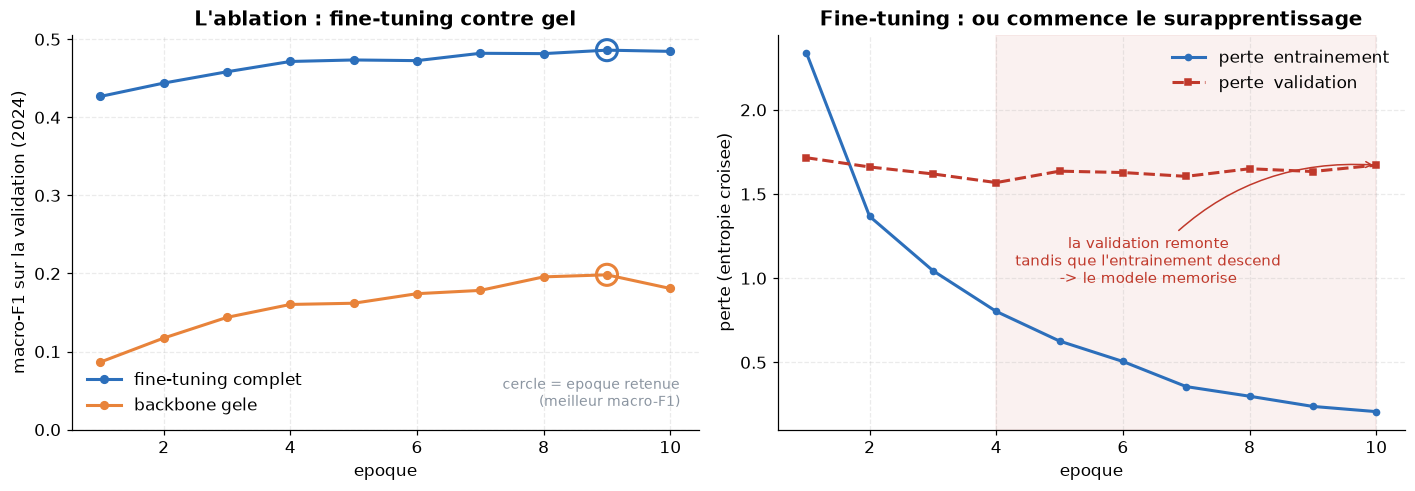

In [10]:
def journal(run_id: str) -> pd.DataFrame:
    """Lit le journal d'entrainement (une ligne par epoque) produit par le CSVLogger de Keras."""
    return pd.read_csv(f"training_log_{run_id}.csv")

fin  = journal("distilbert-base-uncased_finetune_71cl")   # fine-tuning complet
gel  = journal("distilbert-base-uncased_frozen_71cl")     # backbone gele

fig, (g, d) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Gauche : la metrique de pilotage, epoque par epoque ----------------------------------------
for jrn, nom, couleur in ((fin, "fine-tuning complet", BLEU), (gel, "backbone gele", ORANGE)):
    ep = jrn.epoch + 1
    g.plot(ep, jrn.val_f1_macro, "o-", color=couleur, lw=2, ms=5, label=nom)
    # On marque l'epoque retenue : c'est celle dont les poids ont ete sauvegardes.
    meilleure = jrn.val_f1_macro.idxmax()
    g.scatter([ep[meilleure]], [jrn.val_f1_macro[meilleure]], s=190, facecolors="none",
              edgecolors=couleur, lw=2, zorder=5)

g.set(xlabel="epoque", ylabel="macro-F1 sur la validation (2024)", ylim=(0, None))
g.set_title("L'ablation : fine-tuning contre gel")
g.legend(frameon=False)
g.annotate("cercle = epoque retenue\n(meilleur macro-F1)", xy=(0.97, 0.06),
           xycoords="axes fraction", ha="right", fontsize=9, color=GRIS)

# --- Droite : perte d'entrainement et de validation, pour lire le surapprentissage ---------------
ep = fin.epoch + 1
d.plot(ep, fin.loss,     "o-", color=BLEU, lw=2, ms=4, label="perte  entrainement")
d.plot(ep, fin.val_loss, "s--", color=ROUGE, lw=2, ms=4, label="perte  validation")
d.set(xlabel="epoque", ylabel="perte (entropie croisee)")
d.set_title("Fine-tuning : ou commence le surapprentissage")
d.legend(frameon=False)

# L'ecart entre les deux courbes est la signature du surapprentissage : on l'ombre pour le rendre lisible.
divergence = (fin.val_loss.idxmin())
d.axvspan(ep[divergence], ep.iloc[-1], color=ROUGE, alpha=0.07)
# Le texte va dans l'espace vide entre les deux courbes, pas par-dessus la courbe de validation.
d.annotate("la validation remonte\ntandis que l'entrainement descend\n-> le modele memorise",
           xy=(ep.iloc[-1], fin.val_loss.iloc[-1]),
           xytext=(ep.iloc[-1] - 3.6, fin.val_loss.min() * 0.62),
           fontsize=9.5, color=ROUGE, ha="center",
           arrowprops=dict(arrowstyle="->", color=ROUGE, lw=1,
                           connectionstyle="arc3,rad=-0.25"))

plt.tight_layout()
plt.show()

In [11]:
# Le resultat chiffre de l'ablation, lu depuis les deux fichiers d'experience.
a, b = charger("distilbert-base-uncased_finetune_71cl"), charger("distilbert-base-uncased_frozen_71cl")

ablation = pd.DataFrame([
    {"mode": "fine-tuning complet", "taux d'apprentissage": "2e-5",
     "macro-F1 (test 2025)": a["test"]["f1_macro"], "exactitude": a["test"]["accuracy"]},
    {"mode": "backbone gele",       "taux d'apprentissage": "1e-3",
     "macro-F1 (test 2025)": b["test"]["f1_macro"], "exactitude": b["test"]["accuracy"]},
])
print(ablation.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

ecart = a["test"]["f1_macro"] / b["test"]["f1_macro"]
print(f"\nLe fine-tuning complet fait {ecart:.1f} fois mieux que le gel du backbone.")

               mode taux d'apprentissage  macro-F1 (test 2025)  exactitude
fine-tuning complet                 2e-5                0.4671      0.5974
      backbone gele                 1e-3                0.1695      0.2988

Le fine-tuning complet fait 2.8 fois mieux que le gel du backbone.


**Lecture de l'ablation.** L'écart est massif, et il est instructif.

Le backbone gelé produit des représentations *génériques*, apprises sur Wikipedia. Elles séparent
bien les grands thèmes du langage courant, mais pas les nuances qui nous intéressent : distinguer
un débordement de tampon *en écriture* d'un débordement *en lecture* demande une sensibilité que
rien, dans le pré-entraînement généraliste, n'a eu de raison de développer.

Le fine-tuning autorise le backbone à **réorganiser** ses représentations pour notre tâche. C'est
ce qui fait la différence, et c'est pourquoi c'est le mode que nous retenons.

Sur la figure de droite, la remontée de la perte de validation pendant que celle d'entraînement
continue de descendre est la signature classique du surapprentissage : le modèle commence à
mémoriser. C'est exactement ce que l'arrêt anticipé et la sauvegarde de la meilleure époque
neutralisent - nous ne conservons pas les poids de la dernière époque, mais ceux de la meilleure.

---
---
# 5 - La réponse naïve : 97 % d'exactitude

Voici les résultats tels qu'on les présente habituellement.

In [12]:
# Toutes les configurations entrainees, avec leurs metriques de test standard.
CONFIGS = [
    ("DistilBERT · 10 classes",       "distilbert-base-uncased_finetune_10cl"),
    ("DistilBERT · 71 classes",       "distilbert-base-uncased_finetune_71cl"),
    ("DistilBERT · 121 classes",      "distilbert-base-uncased_finetune_121cl"),
    ("DistilBERT · 71 cl. · 218k CVE", "distilbert-base-uncased_finetune_71cl_full"),
    ("SecureBERT · 71 classes",       "SecureBERT_finetune_71cl"),
]

lignes = []
for nom, run_id in CONFIGS:
    r = charger(run_id)
    b = r.get("baselines", {})
    lignes.append({
        "configuration":   nom,
        "classes":         r["config"]["num_classes"],
        "exactitude":      r["test"]["accuracy"],
        "macro-F1":        r["test"]["f1_macro"],
        "F1 pondere":      r["test"]["f1_weighted"],
        "macro-F1 TF-IDF": b.get("tfidf_logreg", {}).get("f1_macro", float("nan")),
    })

labo = pd.DataFrame(lignes)
print("Resultats de test (annee 2025), presentation standard\n")
print(labo.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Resultats de test (annee 2025), presentation standard

                 configuration  classes  exactitude  macro-F1  F1 pondere  macro-F1 TF-IDF
       DistilBERT · 10 classes       10      0.9691    0.9468      0.9692           0.9391
       DistilBERT · 71 classes       71      0.5974    0.4671      0.5761           0.4243
      DistilBERT · 121 classes      121      0.5765    0.4139      0.5517           0.3703
DistilBERT · 71 cl. · 218k CVE       71      0.6447    0.5001      0.6338           0.4638
       SecureBERT · 71 classes       71      0.6097    0.4825      0.5852           0.4243


## Le fine-tuning valait-il le coût ?

La question mérite d'être posée franchement : une régression logistique sur des TF-IDF s'entraîne
en une trentaine de secondes sur un processeur ordinaire. Notre transformer demande plus d'une
heure de GPU. Comparons-les sur la même métrique et le même jeu de test.

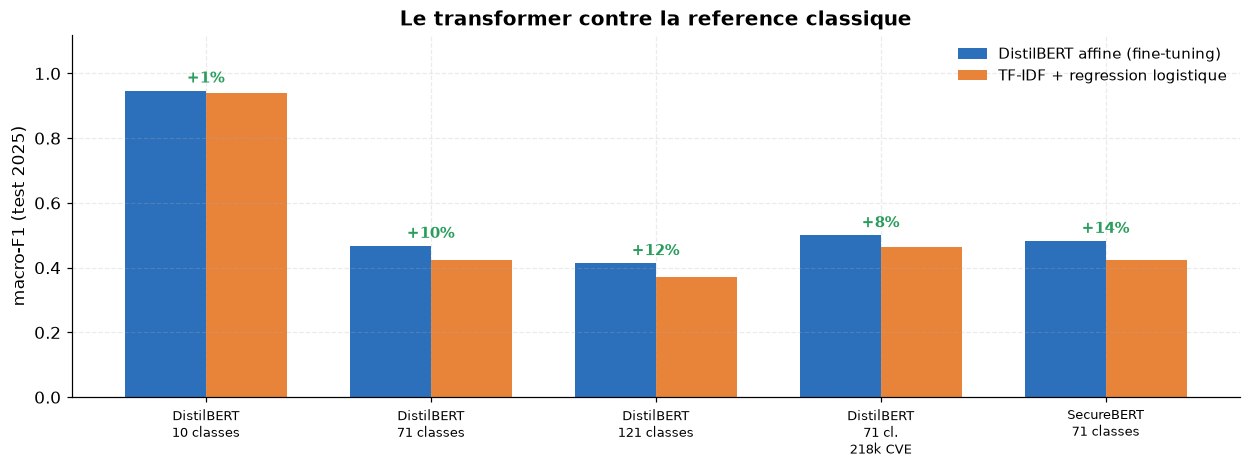

TF-IDF + regression logistique : 33 s d'entrainement sur processeur.
DistilBERT affine              : plus d'une heure sur GPU.

Le gain est reel et systematique, mais il se paie environ 100 fois le temps de calcul.


In [13]:
fig, ax = plt.subplots(figsize=(11.5, 4.4))

x, larg = np.arange(len(labo)), 0.36
ax.bar(x - larg / 2, labo["macro-F1"],        larg, color=BLEU,   label="DistilBERT affine (fine-tuning)")
ax.bar(x + larg / 2, labo["macro-F1 TF-IDF"], larg, color=ORANGE, label="TF-IDF + regression logistique")

# L'ecart relatif est plus parlant que l'ecart absolu : on l'inscrit au-dessus de chaque paire.
for i, (t, b) in enumerate(zip(labo["macro-F1"], labo["macro-F1 TF-IDF"])):
    ax.text(i, max(t, b) + 0.025, f"+{(t / b - 1):.0%}", ha="center",
            fontsize=10, fontweight="bold", color=VERT)

ax.set_xticks(x)
ax.set_xticklabels([n.replace(" · ", "\n") for n in labo.configuration], fontsize=8.5)
ax.set(ylabel="macro-F1 (test 2025)", ylim=(0, 1.12))
ax.set_title("Le transformer contre la reference classique")
ax.legend(frameon=False, loc="upper right", fontsize=9.5)

plt.tight_layout()
plt.show()

# Le cout, lu dans le fichier de la reference : c'est l'autre moitie de l'arbitrage.
secondes = charger("tfidf-logreg_baseline_71cl")["train_seconds"]
print(f"TF-IDF + regression logistique : {secondes:.0f} s d'entrainement sur processeur.")
print(f"DistilBERT affine              : plus d'une heure sur GPU.")
print(f"\nLe gain est reel et systematique, mais il se paie environ 100 fois le temps de calcul.")

**Le fine-tuning gagne partout**, avec un écart d'autant plus net que la tâche est difficile :
sur 10 classes faciles, la référence classique tient presque le rythme ; sur 121 classes, l'écart
se creuse. C'est cohérent avec l'intérêt du pré-entraînement - il sert surtout quand les données
disponibles pour la tâche ne suffisent pas.

Cela valide l'approche du sujet. Mais notons dès maintenant l'ordre de grandeur : **+10 % de
macro-F1 pour environ 100 fois le temps de calcul**. C'est un arbitrage qu'un projet réel devrait
assumer explicitement.

---

Sur le tableau précédent, la configuration à 10 classes atteint **96,9 % d'exactitude**. Présentée
seule, c'est une réussite : le modèle se trompe trois fois sur cent.

**Ce chiffre est pourtant trompeur.** La section suivante explique pourquoi - c'est le résultat dont
nous sommes le plus certains.

---
# 6 - Pourquoi cette réponse est fausse

## La population d'évaluation n'est pas la population de production

Le jeu de test contient **uniquement des CVE dont le vrai type fait partie de notre périmètre**.
C'est cohérent - on ne peut pas reprocher au modèle de rater une classe qu'on ne lui a pas apprise.

Mais en production, ce filtre n'existe pas. Le modèle reçoit **toutes** les CVE de l'année, y compris
celles dont le vrai type est hors périmètre. Et face à l'une d'elles, un softmax **ne peut pas
s'abstenir** : ses sorties somment à 1, il attribue donc nécessairement une probabilité à l'un de
nos types. Il donne un nom. Un nom faux.

Plus le périmètre est étroit, plus il y a de CVE hors périmètre, et plus le modèle produit de faux
noms. **C'est le mécanisme exact qui inverse le classement.**

Mesurons-le.

In [14]:
# Le "contrat" mesure les memes modeles sur la population REELLE : toutes les CVE etiquetees de
# 2025, dans leurs proportions naturelles, sans aucun filtrage par le perimetre.
lignes = []
for nom, run_id in CONFIGS:
    if not (RUNS / f"contrat_{run_id}.json").exists():
        continue
    r, c = charger(run_id), charger(f"contrat_{run_id}")
    lignes.append({
        "configuration":        nom,
        "exactitude (labo)":    r["test"]["accuracy"],
        # part des CVE de 2025 dont le vrai type n'existe pas dans le perimetre du modele
        "part hors perimetre":  1 - c["part_dans_perimetre"],
        # parmi celles-la, la part a laquelle le modele donne quand meme un nom (donc faux)
        "faux noms hors per.":  c["taux_faux_nommage_hors_perimetre"],
        # courbe[0] = sans aucun seuil : la precision brute sur la population reelle complete
        "precision brute":      c["courbe"][0]["precision"],
        "CVE nommees":          c["contrat"]["n_cve"],
    })

prod = pd.DataFrame(lignes)
print("Les memes modeles, sur la population reelle de 2025\n")
print(prod.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Les memes modeles, sur la population reelle de 2025

                 configuration  exactitude (labo)  part hors perimetre  faux noms hors per.  precision brute  CVE nommees
       DistilBERT · 10 classes             0.9691               0.5895               1.0000           0.3979          205
       DistilBERT · 71 classes             0.5974               0.1551               0.7165           0.5955        15476
      DistilBERT · 121 classes             0.5765               0.0916               0.8689           0.5825         5245
DistilBERT · 71 cl. · 218k CVE             0.6447               0.1551               0.6992           0.6402        14326
       SecureBERT · 71 classes             0.6097               0.1551               0.7844           0.6061         8533


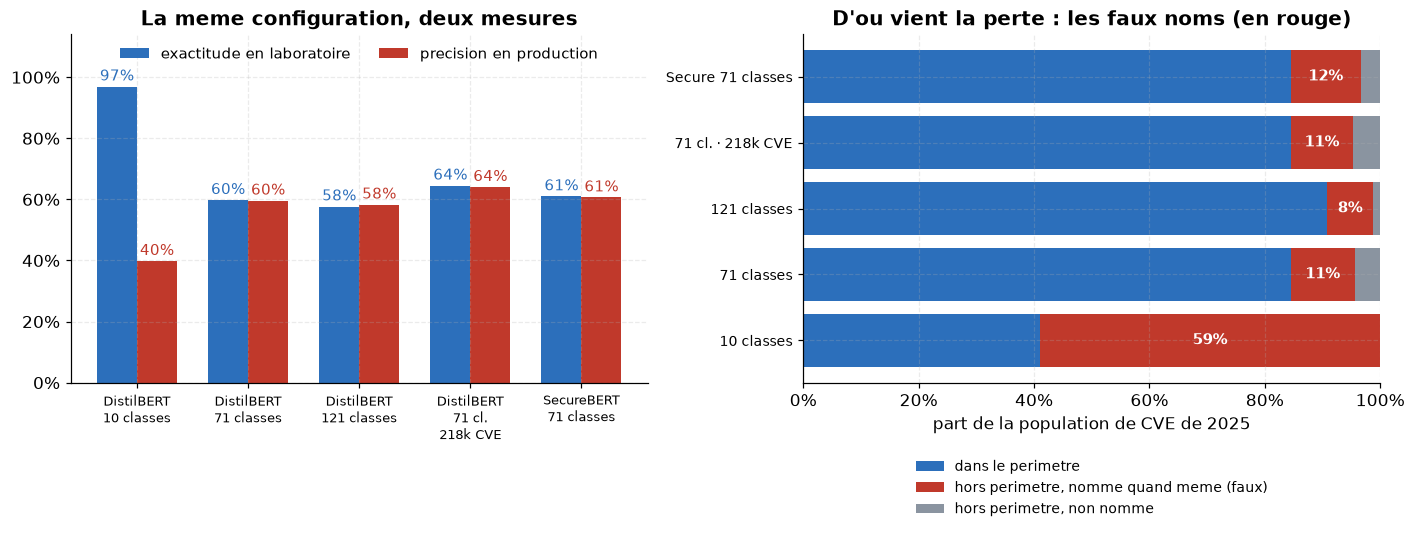

In [15]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13, 5.4))

x = np.arange(len(prod))
larg = 0.36

# --- Gauche : la comparaison directe qui donne son titre a cette section -------------------------
g.bar(x - larg / 2, prod["exactitude (labo)"], larg, color=BLEU,  label="exactitude en laboratoire")
g.bar(x + larg / 2, prod["precision brute"],   larg, color=ROUGE, label="precision en production")

for i, (labo_v, prod_v) in enumerate(zip(prod["exactitude (labo)"], prod["precision brute"])):
    g.text(i - larg / 2, labo_v + 0.02, f"{labo_v:.0%}", ha="center", fontsize=9.5, color=BLEU)
    g.text(i + larg / 2, prod_v + 0.02, f"{prod_v:.0%}", ha="center", fontsize=9.5, color=ROUGE)

g.set_xticks(x)
g.set_xticklabels([n.replace(" · ", "\n") for n in prod.configuration], fontsize=8.5)
g.set(ylabel="", ylim=(0, 1.14))
g.yaxis.set_major_formatter(POURCENT)
g.set_title("La meme configuration, deux mesures")
g.legend(frameon=False, loc="upper center", ncol=2, fontsize=9.5)

# --- Droite : le mecanisme, decompose -- d'ou vient exactement la perte ? ------------------------
# On decompose la population 2025 en trois parts, pour chaque configuration :
#   (a) dans le perimetre                       -> le modele PEUT avoir raison
#   (b) hors perimetre, mais nomme quand meme   -> faux par construction, c'est la perte
#   (c) hors perimetre et laisse de cote        -> sans effet sur la precision
p = prod["part hors perimetre"].values          # part hors perimetre
f = prod["faux noms hors per."].values          # parmi elles, part a laquelle on donne un nom

dans     = 1 - p
faux     = p * f
epargne  = p * (1 - f)

d.barh(x, dans,    color=BLEU,  label="dans le perimetre")
d.barh(x, faux,    left=dans,             color=ROUGE, label="hors perimetre, nomme quand meme (faux)")
d.barh(x, epargne, left=dans + faux,      color=GRIS,  label="hors perimetre, non nomme")

# On inscrit la part de faux noms : c'est le seul chiffre qui compte dans cette figure.
for i, v in enumerate(faux):
    if v > 0.03:
        d.text(dans[i] + v / 2, i, f"{v:.0%}", ha="center", va="center",
               fontsize=9.5, color="white", fontweight="bold")

d.set_yticks(x)
d.set_yticklabels([n.replace("DistilBERT · ", "").replace("SecureBERT · ", "Secure ")
                   for n in prod.configuration], fontsize=9)
d.set(xlabel="part de la population de CVE de 2025", xlim=(0, 1))
d.xaxis.set_major_formatter(POURCENT)
d.set_title("D'ou vient la perte : les faux noms (en rouge)")
d.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.42), fontsize=9)

plt.tight_layout()
plt.show()

## Le résultat

**Le classement s'inverse.** La configuration à 10 classes, la meilleure au laboratoire avec 97 %
d'exactitude, est la **pire** en production. Celle à 71 classes, moins brillante sur le papier, est
celle qui nomme le plus de CVE correctement.

La figure de droite décompose la population et montre d'où vient exactement la perte. La bande
rouge - les CVE hors périmètre auxquelles le modèle donne un nom malgré tout - est du faux **par
construction** : leur vrai type n'existe pas dans la liste, aucune réponse ne peut être juste.

Sur la configuration à 10 classes, cette bande occupe la majeure partie de la population. Ce n'est
pas une corrélation observée sur cinq points, c'est une conséquence arithmétique : le softmax
normalise ses sorties à 1, donc il désigne toujours un gagnant. Il ne dispose d'aucun moyen de
répondre "je ne sais pas".

## Ce que ce résultat nous apprend

> **L'exactitude sur le jeu de test ne prédit pas la valeur en production - elle peut la prédire
> à l'envers.**

Ce n'est pas un défaut de notre modèle : c'est un défaut du **protocole d'évaluation standard**.
Le jeu de test filtré répond à la question "le modèle classe-t-il bien ce qu'il a appris ?".
La production pose une autre question : "que se passe-t-il quand il rencontre ce qu'il n'a pas
appris ?". Les deux réponses ne coïncident pas.

Toute la suite de ce projet découle de là : nous avons cessé d'optimiser le macro-F1 pour optimiser
un **contrat de service**.

---
---
# 7 - La réponse honnête : un contrat de service

## Ce qu'un utilisateur peut réellement demander

Pas "quelle est ton exactitude ?", mais :

> **"Quand tu me donnes un type, à quelle fréquence as-tu raison - et sur quelle part des CVE
> acceptes-tu de te prononcer ?"**

Deux nombres, pas un. Et ils s'échangent l'un contre l'autre : le modèle produit une probabilité,
on ne répond qu'au-dessus d'un **seuil de confiance**. Seuil haut, on répond rarement mais bien ;
seuil bas, on répond souvent et on se trompe davantage.

## Le piège méthodologique : trois façons de mesurer, dont deux sont fausses

Annoncer un contrat suppose d'avoir choisi un seuil. **La manière dont on le choisit change le
chiffre annoncé**, et il existe deux façons de se tromper - dont une que nous avons nous-mêmes
commise avant de la corriger.

**Niveau 1 - le seuil est choisi sur l'année de test.** On cherche le seuil qui donne 90 % de
précision sur 2025, et on annonce "90 % sur 2025". Évidemment. Le chiffre est garanti d'avance :
on a choisi la réponse puis mesuré qu'elle était juste.

**Niveau 2 - le seuil est calibré sur 2024, mais on regarde 2025 pour décider *quelle cible* viser.**
Plus subtil, et c'est l'erreur que contenait notre première version. On balaie plusieurs cibles de
calibration (85 %, 90 %, 95 %...), on applique chacune à 2025, et on retient **celle qui atteint 90 %
sur 2025**. Le seuil n'a jamais vu 2025 - mais le *choix* de la cible, si. La fuite est réelle,
simplement déplacée d'un cran.

**Niveau 3 - la cible est fixée d'avance.** On décide *avant tout* de viser 90 %, on calibre le
seuil sur 2024, on l'applique à 2025 tel quel, et on annonce ce qu'on obtient. Rien de 2025 n'a
influencé quoi que ce soit. **C'est le seul chiffre défendable**, et c'est de loin le moins flatteur.

Nous affichons les trois, parce que l'écart entre eux *est* le résultat.

protocole                                                 precision   couverture    CVE/an
------------------------------------------------------------------------------------------
1. seuil cherche ET mesure sur 2025                          90,0 %       35,8 %    15 476
2. seuil calibre sur 2024, cible choisie en voyant 2025      91,4 %       32,2 %    13 923
3. cible 90 % fixee d'avance, calibree sur 2024              78,3 %       55,3 %    23 921

Les niveaux 1 et 2 annoncent environ 90 % parce qu'ils ont regarde la reponse.
Le niveau 3, seul honnete, donne 78,3 % -- soit 11,7 % d'optimisme evite.
En echange il repond bien plus souvent : 55,3 % du flux contre 35,8 %.


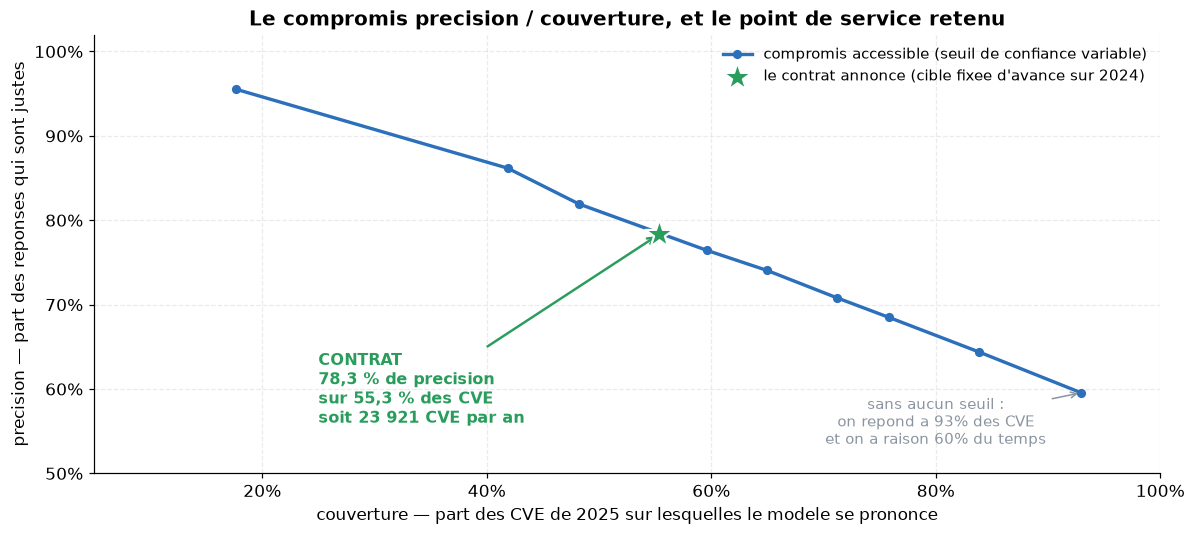

In [16]:
RUN = "distilbert-base-uncased_finetune_71cl"      # la configuration retenue
c   = charger(f"contrat_{RUN}")                   # courbe precision/couverture sur la population reelle
s   = charger(f"seuils_{RUN}")                    # protocole de calibration (2024) -> evaluation (2025)

# Note de provenance : la courbe vient de contrat_precision.py (seuils ronds), les trois niveaux
# de seuils_par_classe.py (seuil exact par tri sur la confiance). Les points peuvent donc differer
# d'un a deux points de precision de la courbe -- meme modele, granularite de calcul differente.
courbe = pd.DataFrame(c["courbe"])

# Les trois niveaux decrits ci-dessus, chacun lu dans le fichier qui le produit.
n1_optimiste = c["contrat"]                       # seuil cherche ET mesure sur 2025
n2_subtil    = s["contrat_hors_echantillon"]      # cible de calibration choisie en regardant 2025
n3_propre    = s["global"]                        # cible 90 % fixee d'avance, calibree sur 2024

contrat = n3_propre                               # LE chiffre que nous annoncons

print(f"{'protocole':<56}{'precision':>11}{'couverture':>13}{'CVE/an':>10}")
print("-" * 90)
for nom, v in (("1. seuil cherche ET mesure sur 2025", n1_optimiste),
               ("2. seuil calibre sur 2024, cible choisie en voyant 2025", n2_subtil),
               ("3. cible 90 % fixee d'avance, calibree sur 2024", n3_propre)):
    print(f"{nom:<56}{pct(v['precision']):>11}{pct(v['couverture']):>13}{milliers(v['n_cve']):>10}")

print(f"\nLes niveaux 1 et 2 annoncent environ 90 % parce qu'ils ont regarde la reponse.")
print(f"Le niveau 3, seul honnete, donne {pct(n3_propre['precision'])} -- soit "
      f"{pct(0.90 - n3_propre['precision'])} d'optimisme evite.")
print(f"En echange il repond bien plus souvent : {pct(n3_propre['couverture'])} du flux "
      f"contre {pct(n1_optimiste['couverture'])}.")

fig, ax = plt.subplots(figsize=(11, 5))

# La courbe complete : chaque point est un seuil de confiance possible.
ax.plot(courbe.couverture, courbe.precision, "o-", color=BLEU, lw=2.2, ms=5,
        label="compromis accessible (seuil de confiance variable)")

# L'extremite droite de la courbe : ce qu'on obtient sans aucun seuil, en repondant a tout.
sans_seuil = courbe.iloc[0]
ax.annotate(f"sans aucun seuil :\non repond a {sans_seuil.couverture:.0%} des CVE\n"
            f"et on a raison {sans_seuil.precision:.0%} du temps",
            xy=(sans_seuil.couverture, sans_seuil.precision),
            xytext=(0.80, 0.535), fontsize=9.5, color=GRIS, ha="center",
            arrowprops=dict(arrowstyle="->", color=GRIS, lw=1))

# Le point de service annonce : cible fixee d'avance, calibree sur 2024, appliquee a 2025.
ax.scatter([contrat["couverture"]], [contrat["precision"]], s=380, marker="*",
           color=VERT, zorder=6, edgecolors="white", lw=1.4,
           label="le contrat annonce (cible fixee d'avance sur 2024)")
ax.annotate(f"CONTRAT\n{pct(contrat['precision'])} de precision\n"
            f"sur {pct(contrat['couverture'])} des CVE\n"
            f"soit {milliers(contrat['n_cve'])} CVE par an",
            xy=(contrat["couverture"], contrat["precision"]),
            xytext=(0.25, 0.56), fontsize=10.5, color=VERT, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=VERT, lw=1.6))

ax.set(xlabel="couverture — part des CVE de 2025 sur lesquelles le modele se prononce",
       ylabel="precision — part des reponses qui sont justes",
       xlim=(0.05, 1), ylim=(0.5, 1.02))
ax.xaxis.set_major_formatter(POURCENT)
ax.yaxis.set_major_formatter(POURCENT)
ax.set_title("Le compromis precision / couverture, et le point de service retenu")
ax.legend(frameon=False, loc="upper right", fontsize=9.5)

plt.tight_layout()
plt.show()

In [17]:
# Le contrat n'est pas un point unique impose : c'est un curseur. Voici ce que donnent les autres
# cibles de calibration, toutes mesurees selon le protocole propre (cible fixee, calibree sur 2024).
balayage = pd.DataFrame(s["balayage_cible_calibration"])

print("Autres points de service accessibles avec le meme modele\n")
print(f"{'cible visee sur 2024':<22}{'precision 2025':>16}{'couverture 2025':>18}{'CVE/an':>10}")
print("-" * 66)
for _, r in balayage.iterrows():
    marque = "  <- retenu" if abs(r.cible_cal - 0.90) < 1e-9 else ""
    print(f"{pct(r.cible_cal, 1):<22}{pct(r.precision_test):>16}"
          f"{pct(r.couverture_test):>18}{milliers(r.n_cve):>10}{marque}")

print("\nViser plus haut fonctionne, mais le prix est brutal : passer de 78 % a 98 % de precision")
print("fait tomber la couverture de 55 % a 5 %. C'est un arbitrage metier, pas un choix technique.")

Autres points de service accessibles avec le meme modele

cible visee sur 2024    precision 2025   couverture 2025    CVE/an
------------------------------------------------------------------
85,0 %                          73,9 %            65,3 %    28 210
90,0 %                          78,3 %            55,3 %    23 921  <- retenu
95,0 %                          91,4 %            32,2 %    13 923
97,0 %                          97,8 %             5,0 %     2 146
98,0 %                          97,9 %             1,0 %       427
99,0 %                          98,3 %             0,8 %       347
99,5 %                          99,3 %             0,3 %       150

Viser plus haut fonctionne, mais le prix est brutal : passer de 78 % a 98 % de precision
fait tomber la couverture de 55 % a 5 %. C'est un arbitrage metier, pas un choix technique.


## Le contrat retenu

> Sur les CVE publiées en 2025, avec un seuil fixé **avant** de les voir, le modèle se prononce sur
> **environ 55 % d'entre elles** et **a raison un peu plus de 78 % du temps**.

C'est nettement moins que les 97 % de la section 5. C'est aussi le seul des trois chiffres qu'on
puisse défendre, parce que c'est le seul qui n'a rien appris de l'année sur laquelle il est mesuré.

L'écart entre le 90 % visé et le 78 % obtenu mérite d'être nommé : **c'est la dérive temporelle**.
Le seuil qui garantissait 90 % de précision sur les CVE de 2024 n'en garantit plus que 78 % sur
celles de 2025. Le vocabulaire des vulnérabilités a bougé en un an, et le modèle est un peu moins
bien calibré qu'il ne l'était. Un système en production devrait donc **se recalibrer
périodiquement** - c'est une conséquence opérationnelle directe de cette mesure.

Enfin, c'est la seule formulation qui permet à un utilisateur de décider s'il veut du système. Un
analyste qui reçoit un type de faille fiable à 78 % sur la moitié de son flux peut construire un
processus dessus. Une exactitude de 97 % mesurée sur une population qu'il ne verra jamais ne lui
sert à rien.

> **Quel modèle livrer ?** Ce chiffre est celui de la configuration entraînée sur 40 000 CVE, qui
> sert de **référence à toutes les ablations** - c'est contre elle que chaque test à variable unique
> a été mené. Mais la section 8 montre que le modèle entraîné sur les **218 000 CVE la domine sur
> les deux axes** : **81,5 % de précision sur 57,9 % du flux**, soit 25 016 CVE par an dont environ
> 20 400 correctement typées. **C'est lui qu'il faut déployer** ; le 40 000 reste l'étalon de
> comparaison.

## Sur quelle population, exactement ?

La question mérite d'être posée une fois de plus, parce que c'est le piège qui nous a déjà eus deux
fois. Notre "population réelle" est celle des CVE de 2025 **qui ont un CWE**. Or l'usage naturel
d'un tel modèle serait justement de traiter celles qui n'en ont pas.

Une objection sérieuse consiste à dire que ces CVE-là sont systématiquement les plus difficiles -
avis laconiques, sources non-NVD - et que notre contrat ne tiendrait pas sur elles. Mesurons
l'ampleur du problème avant de trancher.

In [18]:
# Statistiques de population precalculees (runs/population_cible.json) : elles viennent du
# jeu de donnees source, que ce notebook n'a pas besoin de charger.
pop = charger("population_cible")

print(f"CVE publiees en {pop['annee']} : {milliers(pop['n_cve_publiees'])}\n")
print(f"  avec un CWE  -> DANS notre population d'evaluation : "
      f"{milliers(pop['n_avec_cwe'])}  ({pct(pop['part_couverte_par_notre_evaluation'])})")
print(f"  sans CWE     -> hors de notre evaluation           : {milliers(pop['n_sans_cwe'])}\n")
print("  Detail de ces CVE sans CWE :")
for statut, n in pop["detail_statuts_sans_cwe"].items():
    marque = "  <- ce ne sont PAS des vulnerabilites" if statut == "Rejected" else ""
    print(f"     {statut:<20}{milliers(n):>7}{marque}")
print(f"\n  -> angle mort reel (ni etiquetees, ni rejetees) : "
      f"{milliers(pop['n_angle_mort'])} CVE, soit {pct(pop['part_angle_mort'], 2)} de l'annee")

CVE publiees en 2025 : 45 275

  avec un CWE  -> DANS notre population d'evaluation : 43 240  (95,5 %)
  sans CWE     -> hors de notre evaluation           : 2 035

  Detail de ces CVE sans CWE :
     Rejected              1 630  <- ce ne sont PAS des vulnerabilites
     Awaiting Analysis       322
     Analyzed                 52
     Modified                 22
     Deferred                  8
     Received                  1

  -> angle mort reel (ni etiquetees, ni rejetees) : 405 CVE, soit 0,89 % de l'annee


**L'objection est fondée sur le principe, mais son ampleur est faible.**

Notre évaluation couvre **95,5 % des CVE publiées en 2025**. Sur les 2 035 restantes, **1 630 sont
des CVE rejetées** - retirées du catalogue parce que ce ne sont pas des vulnérabilités. Leur
prédire un type de faille n'aurait aucun sens.

L'angle mort réel - des CVE bien réelles, en attente d'analyse - représente **405 CVE, soit 0,9 %
de l'année**. Notre contrat pourrait y être plus faible ; il ne peut pas s'y effondrer, faute de
volume.

> **Ce que nous ne pouvons pas mesurer, et qu'il faut dire.** Le bon test serait de prédire à partir
> de la description telle qu'elle existait **à la publication**, puis de comparer au CWE attribué
> plus tard par le NVD. Notre jeu de données est un instantané : il ne conserve ni l'historique des
> descriptions, ni la date d'attribution du CWE. Ce test exigerait de rapatrier les flux de
> modifications du NVD - c'est une nouvelle collecte, pas une re-mesure. Nous le signalons comme
> une **limite connue et non levée**.

---
---
# 8 - Onze pistes testées, et un bilan qu'il a fallu refaire

Une fois le contrat en place, nous avions une mesure fiable - donc de quoi tester des améliorations
sans nous raconter d'histoires. Nous avons formulé onze hypothèses, chacune implémentée, entraînée
si nécessaire, et évaluée.

**Notre premier bilan concluait que les onze étaient réfutées. Il était faux.**

Nous le racontons plutôt que de le corriger en silence, parce que l'erreur est la même que celle de
la section 6 - commise cette fois par nous, et sur le sujet même où nous venions de mettre en garde.

## L'erreur

Pour comparer les configurations, nous demandions à chacune d'atteindre **exactement 90 % de
précision**, puis nous regardions laquelle couvrait le plus de CVE. Le problème est dans la façon
dont ce seuil de 90 % était obtenu : **cherché sur l'année de test**. C'est le "niveau 1" de la
section 7, celui que nous venions de qualifier de fuite.

Toutes les configurations étaient traitées de la même façon, ce qui donnait au procédé une apparence
d'équité. Mais un seuil ajusté sur la réponse ne classe pas les modèles selon ce qu'ils valent, il
les classe selon la facilité avec laquelle on peut les forcer à 90 %.

## Le bilan corrigé

Au protocole honnête, les deux axes du contrat bougent - on ne peut donc plus comparer un seul
nombre. Le critère devient une **relation de domination** : une piste n'aide que si elle améliore
**à la fois** la précision et la couverture. Ce critère est mécanique et ne laisse aucune latitude
de rédaction.

Nous ajoutons la seule quantité qui compte pour un utilisateur : le nombre de **CVE correctement
nommées par an**, soit précision x nombre de réponses.

In [19]:
# Bilan produit par bilan_pistes.py, qui mesure chaque piste sous LES DEUX protocoles.
# Le verdict est mecanique -- domination sur les deux axes du contrat -- et non redige a la main.
bp = charger("bilan_pistes")
r3 = bp["reference"]["niveau3"]

print(f"Reference : {milliers(r3['n_cve'])} CVE nommees a {pct(r3['precision'])} de precision, "
      f"soit {milliers(bp['reference']['niveau3_n_justes'])} CVE JUSTES par an\n")

print(f"{'piste':<40}{'ancien bilan':>14}{'precision':>11}{'couverture':>12}"
      f"{'CVE justes/an':>15}{'verdict':>10}")
print("-" * 102)
for l in sorted(bp["pistes"], key=lambda x: -x["ecart_justes"]):
    print(f"{l['piste']:<40}{l['niveau1_ecart']:>+14,}".replace(",", " ")
          + f"{l['ecart_precision']:>+11.1%}{l['ecart_couverture']:>+12.1%}"
          + f"{l['ecart_justes']:>+15,}".replace(",", " ")
          + f"{l['verdict']:>10}")

aide = [l for l in bp["pistes"] if l["verdict"] == "AIDE"]
print(f"\nColonne 'ancien bilan' : ce que disait le protocole fuite -- toutes les pistes negatives.")
print(f"Colonne 'CVE justes/an' : ce que dit le protocole honnete -- {len(aide)} piste ameliore.")

Reference : 23 921 CVE nommees a 78,3 % de precision, soit 18 732 CVE JUSTES par an

piste                                     ancien bilan  precision  couverture  CVE justes/an   verdict
------------------------------------------------------------------------------------------------------
5 fois plus de donnees (218k CVE)               -1 150      +3.2%       +2.5%         +1 668      AIDE
Elargir le perimetre a 121 classes             -10 231      -0.8%       +1.4%           +291   ambigue
Sorties sigmoides (abstention possible)        -12 893      +1.2%       -1.2%           -120   ambigue
Modele de domaine (SecureBERT)                  -6 943      +0.4%       -1.6%           -446   ambigue
Restreindre a 10 classes                       -15 271     +10.9%      -49.0%        -16 305   ambigue

Colonne 'ancien bilan' : ce que disait le protocole fuite -- toutes les pistes negatives.
Colonne 'CVE justes/an' : ce que dit le protocole honnete -- 1 piste ameliore.


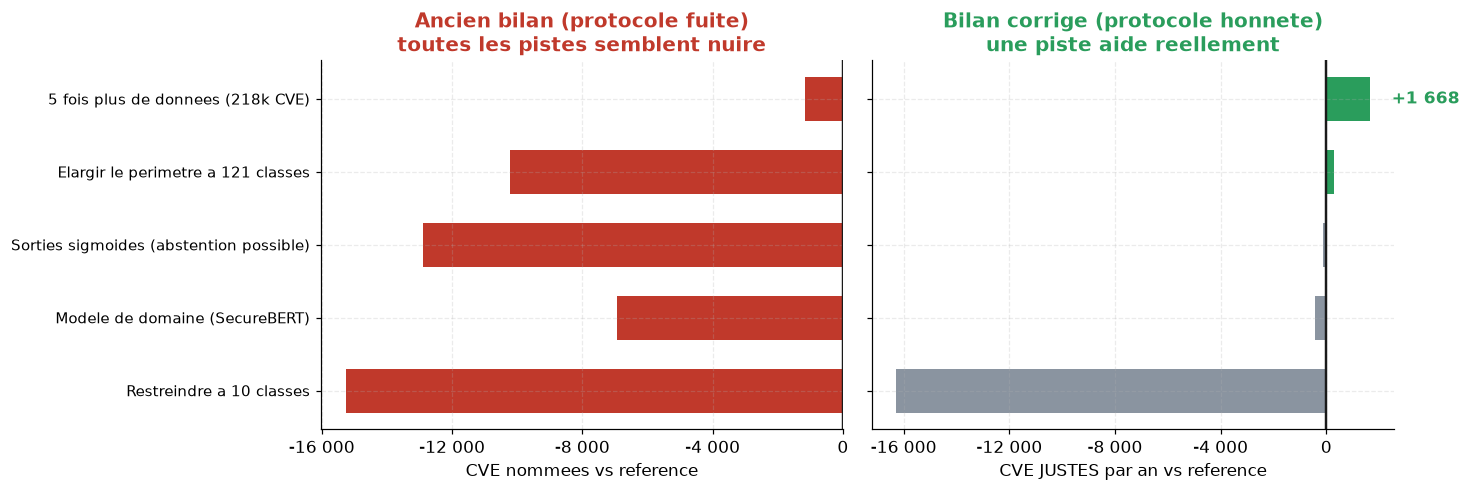

In [20]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
ordre = sorted(bp["pistes"], key=lambda x: x["ecart_justes"])
y = range(len(ordre))
lib = [l["piste"] for l in ordre]

# --- Gauche : l'ANCIEN bilan, au protocole fuite. Tout est negatif. -----------------------------
e1 = [l["niveau1_ecart"] for l in ordre]
g.barh(y, e1, color=ROUGE, height=0.6)
g.axvline(0, color="#1a1a1a", lw=1.6)
g.set_yticks(y); g.set_yticklabels(lib, fontsize=9.5)
g.set(xlabel="CVE nommees vs reference")
g.xaxis.set_major_formatter(MILLIERS)
# Moins de graduations : par defaut les etiquettes a cinq chiffres se chevauchent.
g.xaxis.set_major_locator(plt.MaxNLocator(5))
g.set_title("Ancien bilan (protocole fuite)\ntoutes les pistes semblent nuire", color=ROUGE)

# --- Droite : le bilan CORRIGE, au protocole honnete. Une piste passe au vert. -------------------
e3 = [l["ecart_justes"] for l in ordre]
d.barh(y, e3, color=[VERT if x > 0 else GRIS for x in e3], height=0.6)
d.axvline(0, color="#1a1a1a", lw=1.6)
d.set(xlabel="CVE JUSTES par an vs reference")
d.xaxis.set_major_formatter(MILLIERS)
d.xaxis.set_major_locator(plt.MaxNLocator(5))
d.set_title("Bilan corrige (protocole honnete)\nune piste aide reellement", color=VERT)

# On nomme la piste qui change de camp : c'est tout le propos de la figure.
i_aide = next(i for i, l in enumerate(ordre) if l["verdict"] == "AIDE")
d.annotate(f"+{milliers(e3[i_aide])}", xy=(e3[i_aide], i_aide), xytext=(14, 0),
           textcoords="offset points", va="center", fontsize=11, fontweight="bold", color=VERT)

plt.tight_layout()
plt.show()

## Ce que le protocole honnête révèle

> **Le levier le plus banal de l'apprentissage profond - plus de données - fonctionne.**
> Le modèle entraîné sur 218 000 CVE au lieu de 40 000 gagne **3,2 points de précision et
> 2,5 points de couverture en même temps**, soit environ **1 700 CVE correctement nommées de plus
> par an**. C'est la seule piste qui domine la référence sur les deux axes.

L'ancien bilan la classait parmi les échecs, avec −1 150 CVE. Les deux mesures portent sur les
mêmes modèles et les mêmes données ; seul le protocole change.

**Les quatre autres ne dominent sur aucun des deux axes** - elles échangent de la précision contre
de la couverture, ou l'inverse. Aucune n'est "réfutée" au sens strict, aucune n'aide non plus :

- **121 classes** gagne 1,4 point de couverture et perd 0,8 de précision - un déplacement, pas un gain
- **SecureBERT** et les **sigmoïdes** sont à quelques centaines de CVE justes de la référence,
  dans les deux sens : indistinguables
- **10 classes** est le cas extrême : +10,9 points de précision pour **−49 de couverture**. Le
  critère de domination le classe "ambigu", le bon sens le classe désastreux - **16 300 CVE
  justes en moins par an**. C'est pourquoi nous affichons aussi le nombre de réponses justes :
  la domination seule est trop grossière pour arbitrer un échange aussi déséquilibré.

## La leçon, et c'est la troisième fois

| Section 6 | Le protocole d'évaluation classait les modèles **à l'envers** |
| :-- | :-- |
| Section 7 | Le protocole de calibration produisait un chiffre **optimiste de 12 points** |
| **Section 8** | Le protocole de comparaison nous a fait **rejeter un levier qui fonctionne** |

Trois fois, le même mécanisme : une décision de mesure prise sans y penser, qui a orienté une
conclusion. La troisième fois, nous l'avions déjà écrite deux fois - et nous y sommes tombés
quand même.

C'est le résultat le plus transférable de ce travail, et il ne porte pas sur les CWE.

## Les six autres pistes

Elles ne se mesurent pas en "CVE nommées" et méritent chacune un mot.

In [21]:
# Ces pistes se mesurent sur d'autres axes -- on va chercher chaque chiffre dans son fichier.
casc = charger(f"cascade_{RUN}")
hier = charger("hierarchie_distilbert-base-uncased_finetune_71cl_full")
hmul = charger("distilbert-base-uncased_hierarchique_71cl")
sigm = charger("distilbert-base-uncased_sigmoidesimple_71cl")
base = charger(RUN)
seui = charger(f"seuils_{RUN}")

autres = [
    # ATTENTION a la lecture : la precision seule fait croire a un gain. C'est un simple deplacement
    # sur la courbe precision/couverture -- au total le systeme nomme MOINS de CVE.
    ("Seuil ajuste classe par classe",
     f"{pct(seui['par_classe']['precision'])} de precision sur {pct(seui['par_classe']['couverture'])} "
     f"de couverture, soit {milliers(seui['par_classe']['n_cve'])} CVE nommees -- contre "
     f"{pct(seui['global']['precision'])} sur {pct(seui['global']['couverture'])} et "
     f"{milliers(seui['global']['n_cve'])} CVE avec un seuil unique : "
     f"{milliers(seui['global']['n_cve'] - seui['par_classe']['n_cve'])} CVE nommees EN MOINS",
     "les classes faciles pourraient se permettre de repondre plus souvent"),

    ("Detecteur hors perimetre en cascade",
     f"le detecteur marche (AUC {casc['auc_detecteur']['test']:.3f}), mais l'ajouter donne "
     f"{pct(casc['resultats']['cascade']['precision'])} de precision contre "
     f"{pct(casc['resultats']['classifieur_seul']['precision'])} sans lui : aucun gain",
     "filtrer d'abord les CVE hors perimetre avant de classer les autres"),

    ("Bucket CWE-OTHER explicite",
     f"ne capte que {pct(base['seuil']['recall_other_sur_hors_perimetre'])} des CVE hors perimetre",
     "apprendre au modele a dire 'autre chose' -- il l'utilise trop peu"),

    ("Post-traitement hierarchique (remontee)",
     f"reponses exactes : {pct(hier['test']['reponses_exactes'])} seulement, "
     f"granularite moyenne {hier['test']['granularite_moyenne']:.1f} classes",
     "repondre 'famille memoire' plutot que se tromper de CWE precis -- devient trop vague"),

    ("Entrainement multi-etiquette hierarchique",
     f"macro-F1 {hmul['test']['f1_macro']:.3f} contre {base['test']['f1_macro']:.3f}",
     "apprendre les ancetres en meme temps que la classe"),

    ("Sigmoides seules (test a variable unique)",
     f"macro-F1 {sigm['test']['f1_macro']:.3f} contre {base['test']['f1_macro']:.3f}",
     "isoler l'effet de la sigmoide, sans la hierarchie"),
]

for titre, resultat, intuition in autres:
    print(f"  {titre}")
    print(f"     intuition : {intuition}")
    print(f"     mesure    : {resultat}\n")

  Seuil ajuste classe par classe
     intuition : les classes faciles pourraient se permettre de repondre plus souvent
     mesure    : 82,5 % de precision sur 47,2 % de couverture, soit 20 419 CVE nommees -- contre 78,3 % sur 55,3 % et 23 921 CVE avec un seuil unique : 3 502 CVE nommees EN MOINS

  Detecteur hors perimetre en cascade
     intuition : filtrer d'abord les CVE hors perimetre avant de classer les autres
     mesure    : le detecteur marche (AUC 0.859), mais l'ajouter donne 78,1 % de precision contre 78,4 % sans lui : aucun gain

  Bucket CWE-OTHER explicite
     intuition : apprendre au modele a dire 'autre chose' -- il l'utilise trop peu
     mesure    : ne capte que 28,3 % des CVE hors perimetre

  Post-traitement hierarchique (remontee)
     intuition : repondre 'famille memoire' plutot que se tromper de CWE precis -- devient trop vague
     mesure    : reponses exactes : 11,4 % seulement, granularite moyenne 7.2 classes

  Entrainement multi-etiquette hierarchique
   

## Le cas des données, sous trois éclairages

C'est le plus instructif du notebook, parce qu'il donne **trois réponses différentes à la même
question** selon ce qu'on choisit de mesurer.

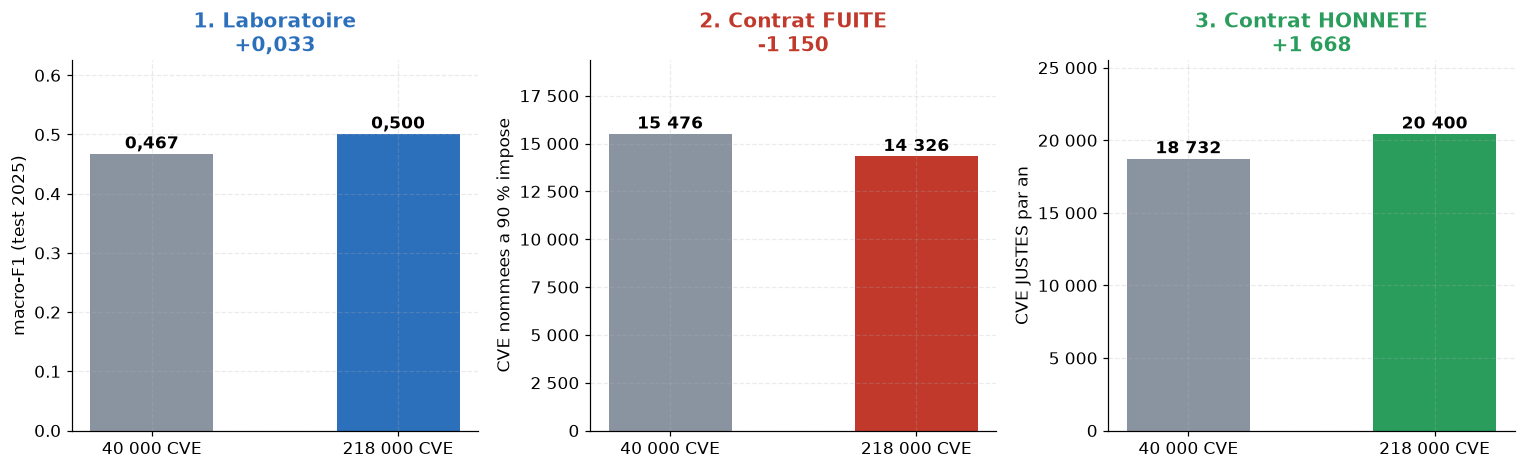

Trois mesures, trois verdicts, sur LES MEMES deux modeles :
   1, laboratoire (macro-F1)      : +0,033  -> aide
   2. contrat fuite  (niveau 1)   : -1 150 CVE  -> semble nuire
   3. contrat honnete (niveau 3)  : +1 668 CVE justes  -> aide


In [22]:
petit, grand = charger(RUN), charger("distilbert-base-uncased_finetune_71cl_full")
n1_p, n1_g = charger(f"contrat_{RUN}")["contrat"], charger("contrat_distilbert-base-uncased_finetune_71cl_full")["contrat"]
n3_p = charger(f"seuils_{RUN}")["global"]
n3_g = charger("seuils_distilbert-base-uncased_finetune_71cl_full")["global"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
etiq = ["40 000 CVE", "218 000 CVE"]

# 1. le laboratoire : macro-F1. Plus de donnees aide -- comme attendu.
v = [petit["test"]["f1_macro"], grand["test"]["f1_macro"]]
axes[0].bar(etiq, v, color=[GRIS, BLEU], width=0.5)
axes[0].set(ylabel="macro-F1 (test 2025)", ylim=(0, max(v) * 1.25))
# Le remplacement du point decimal ne doit porter QUE sur le nombre : applique au titre
# entier, il transformerait "1." en "1,".
axes[0].set_title("1. Laboratoire\n+" + f"{v[1]-v[0]:.3f}".replace(".", ","), color=BLEU)

# 2. le contrat FUITE : seuil cherche sur l'annee de test. Plus de donnees semble NUIRE.
v1 = [n1_p["n_cve"], n1_g["n_cve"]]
axes[1].bar(etiq, v1, color=[GRIS, ROUGE], width=0.5)
axes[1].set(ylabel="CVE nommees a 90 % impose", ylim=(0, max(v1) * 1.25))
axes[1].set_title("2. Contrat FUITE\n" + f"{v1[1]-v1[0]:+,}".replace(",", " "), color=ROUGE)

# 3. le contrat HONNETE : cible fixee d'avance. Plus de donnees aide, sur les deux axes.
v3 = [n3_p["precision"] * n3_p["n_cve"], n3_g["precision"] * n3_g["n_cve"]]
axes[2].bar(etiq, v3, color=[GRIS, VERT], width=0.5)
axes[2].set(ylabel="CVE JUSTES par an", ylim=(0, max(v3) * 1.25))
axes[2].set_title("3. Contrat HONNETE\n+" + f"{v3[1]-v3[0]:,.0f}".replace(",", " "), color=VERT)

for ax, vals, fmt in zip(axes, (v, v1, v3), ("{:.3f}", "{:,.0f}", "{:,.0f}")):
    for i, x in enumerate(vals):
        ax.text(i, x * 1.02, fmt.format(x).replace(",", " ").replace(".", ","),
                ha="center", fontsize=11, fontweight="bold")
    ax.yaxis.set_major_formatter(MILLIERS) if fmt != "{:.3f}" else None

plt.tight_layout()
plt.show()

print(f"Trois mesures, trois verdicts, sur LES MEMES deux modeles :")
print(f"   1. laboratoire (macro-F1)      : +{v[1]-v[0]:.3f}  -> aide".replace(".", ","))
print(f"   2. contrat fuite  (niveau 1)   : {v1[1]-v1[0]:+,} CVE  -> semble nuire".replace(",", " "))
print(f"   3. contrat honnete (niveau 3)  : +{v3[1]-v3[0]:,.0f} CVE justes  -> aide".replace(",", " "))

**Les trois colonnes portent sur les deux mêmes modèles, entraînés une seule fois.**
Seule la question posée change.

La deuxième est celle que nous avions retenue dans notre premier bilan, et elle nous a fait écrire
que cinq fois plus de données ne rapportait rien. C'était une conséquence du protocole, pas une
propriété du modèle.

**Ce qu'il faut en retenir n'est pas "plus de données aide"** - c'est banal. C'est que la même
expérience, sur les mêmes fichiers, rend trois verdicts différents selon une décision de mesure
qu'on prend souvent sans y penser.

## Deux autres commentaires

**Le seuil par classe, et le piège de lecture qu'il tend.** Sa précision est de 82,5 % contre 78,3 %
pour un seuil unique. Lue seule, cette ligne ressemble à un gain de 4 points - et c'est exactement
ainsi qu'on se trompe. Regardez la couverture : elle tombe de 55 % à 47 %, et le système nomme
**3 500 CVE de moins**. Ce n'est pas une amélioration, c'est un **déplacement sur la même courbe**,
qu'on aurait obtenu tout aussi bien en montant le seuil unique. C'est la raison pour laquelle un
contrat doit toujours s'énoncer en **deux nombres**.

**Le modèle de domaine.** SecureBERT est pré-entraîné sur du texte de cybersécurité - il devrait
partir avec un avantage sur notre vocabulaire. Au protocole honnête, il est **indistinguable** de
DistilBERT : 446 CVE justes d'écart sur 18 700. L'explication la plus plausible : le vocabulaire des
descriptions de CVE est très stéréotypé, et DistilBERT a largement assez d'exemples pour l'apprendre
en fine-tuning. L'avantage du pré-entraînement spécialisé s'évapore dès qu'on a de quoi spécialiser
un modèle généraliste.

---
---
# 9 - La douzième piste : changer la question

Les onze pistes de la section 8 partagent un présupposé que nous n'avions jamais interrogé : elles
cherchent toutes à **mieux prédire 71 classes**. Modèle plus gros, plus de données, autre fonction
d'activation, post-traitement - la cible, elle, ne bouge pas. La meilleure d'entre elles, cinq fois
plus de données, rapporte environ 1 700 CVE justes par an.

La douzième piste s'attaque à la cible : **71 classes, est-ce la bonne granularité ?**

## Pourquoi ce n'est PAS "réduire à 10 classes", qui a échoué

La distinction est essentielle, et nous l'avions manquée. Ce sont deux opérations **opposées** :

| | Réduire le périmètre *(piste réfutée)* | Changer la granularité *(cette piste)* |
|---|---|---|
| Principe | garder les 10 CWE les plus fréquents | ranger **les 969 CWE** dans une famille |
| Ce qu'on fait du reste | jeté **hors périmètre** | **absorbé** dans une famille |
| Part hors périmètre obtenue | 59 % des CVE | ~0 % |

Rétrécir le périmètre **aggrave** le problème central de la section 6 : plus de CVE dont le vrai
type n'existe pas dans la liste, donc plus de faux noms. Repartitionner **le supprime** : tout CWE
appartient à une famille, il n'y a plus de "hors périmètre" à inventer.

Nous avions rangé "moins de classes" parmi les échecs. C'était une généralisation abusive.

## Quelle partition ?

Pas une invention de notre part : **les 10 `Pillar` officiels de MITRE**, c'est-à-dire la racine
de l'arbre présenté en section 2 - plus un bucket `autre` pour les CWE non rattachés. Onze
familles, définies par la taxonomie elle-même.

Et pour ne pas conclure trop vite, nous avons testé la granularité famille de **deux façons
indépendantes** - parce qu'elles pouvaient donner des résultats opposés :

- **B - relire** le modèle à 71 classes, en additionnant ses probabilités par famille
- **C - entraîner** un modèle directement sur les 11 familles

Ce n'est pas une redondance. Entraîner sur 11 familles **jette** l'information qui sépare CWE-89 de
CWE-79 à l'intérieur de `neutralization`. Le modèle fin, lui, l'a apprise, et l'agrégation de ses
probabilités préserve la structure de confiance qui en découle. Il était parfaitement possible que
la supervision fine batte la supervision grossière.

In [23]:
# Analyse produite par comparaison_granularite.py. Les trois configurations partagent TOUT :
# meme backbone, meme budget (40 000 exemples), meme graine, meme population de test 2025, et le
# meme protocole hors echantillon qu'en section 7. Seule la cible change.
# NOTE DE PROVENANCE : la ligne A reproduit le contrat de la section 7 a l'arrondi pres
# (78,1 / 55,7 contre 78,3 / 55,3). Les deux scripts cherchent le seuil differemment -- par tri
# exact ici, par balayage de cibles la-bas. Le chiffre canonique du notebook reste celui de la
# section 7 ; A sert ici de point de comparaison interne, sur le meme modele que B et C.
cg = charger("comparaison_granularite")
A, B, C = (cg["A_71_classes_cible_fine"], cg["B_71_classes_relue_famille"],
           cg["C_11_familles_entrainee"])

print(f"{'configuration':<36}{'precision':>12}{'couverture':>13}{'CVE/an':>10}")
print("-" * 71)
for nom, v in (("A. 71 classes, cible fine", A),
               ("B. 71 classes, RELUE en famille", B),
               ("C. 11 familles, ENTRAINEE", C)):
    print(f"{nom:<36}{pct(v['precision']):>12}{pct(v['couverture']):>13}{milliers(v['n_cve']):>10}")

print(f"\nchangement de granularite (A -> famille) : "
      f"+{milliers(min(B['n_cve'], C['n_cve']) - A['n_cve'])} a "
      f"+{milliers(max(B['n_cve'], C['n_cve']) - A['n_cve'])} CVE nommees par an")
print(f"choix entre les deux facons d'y arriver  : "
      f"{milliers(abs(C['n_cve'] - B['n_cve']))} CVE d'ecart -- deux ordres de grandeur en dessous")

configuration                          precision   couverture    CVE/an
-----------------------------------------------------------------------
A. 71 classes, cible fine                 78,1 %       55,7 %    24 063
B. 71 classes, RELUE en famille           89,2 %       86,6 %    37 420
C. 11 familles, ENTRAINEE                 89,6 %       87,1 %    37 671

changement de granularite (A -> famille) : +13 357 a +13 608 CVE nommees par an
choix entre les deux facons d'y arriver  : 251 CVE d'ecart -- deux ordres de grandeur en dessous


> **La précision monte de 11 points et la couverture de 31 points, en même temps.**

C'est ce qui rend ce résultat différent de tous les précédents. Jusqu'ici, chaque gain de précision
se payait en couverture - nous nous déplacions sur une courbe. Ici **c'est la courbe entière qui
se déplace**.

Et les deux chemins, B et C, arrivent pratiquement au même endroit. Nous y revenons juste après.

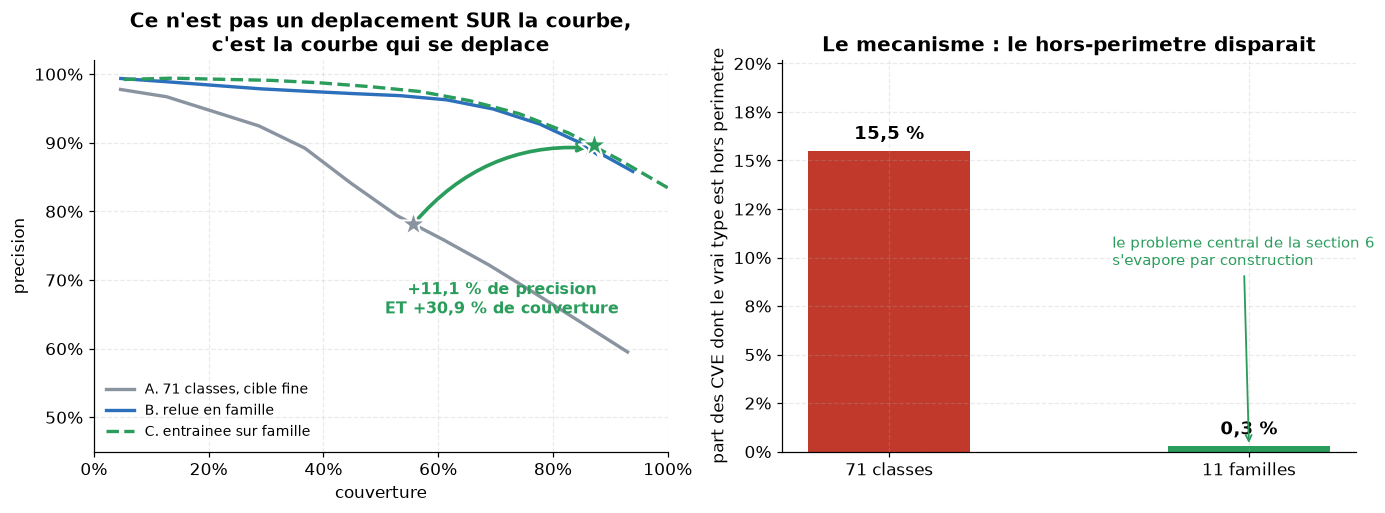

In [24]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13, 4.8))

# --- Gauche : les trois courbes de compromis --------------------------------------------------
for cle, etiq, couleur, style in (("courbe_A", "A. 71 classes, cible fine", GRIS, "-"),
                                  ("courbe_B", "B. relue en famille", BLEU, "-"),
                                  ("courbe_C", "C. entrainee sur famille", VERT, "--")):
    c = pd.DataFrame(cg[cle])
    g.plot(c.couverture, c.precision, style, color=couleur, lw=2.2, label=etiq)

for v, couleur in ((A, GRIS), (B, BLEU), (C, VERT)):
    g.scatter([v["couverture"]], [v["precision"]], s=300, marker="*", color=couleur,
              zorder=6, edgecolors="white", lw=1.3)

# La fleche materialise le deplacement de la courbe : c'est le message de la figure.
g.annotate("", xy=(B["couverture"], B["precision"]), xytext=(A["couverture"], A["precision"]),
           arrowprops=dict(arrowstyle="->", color=VERT, lw=2.4,
                           connectionstyle="arc3,rad=-0.25"))
g.text((A["couverture"] + B["couverture"]) / 2, A["precision"] - 0.13,
       f"+{pct(B['precision'] - A['precision'])} de precision\n"
       f"ET +{pct(B['couverture'] - A['couverture'])} de couverture",
       ha="center", fontsize=10.5, fontweight="bold", color=VERT)

g.set(xlabel="couverture", ylabel="precision", xlim=(0, 1), ylim=(0.45, 1.02))
g.xaxis.set_major_formatter(POURCENT)
g.yaxis.set_major_formatter(POURCENT)
g.set_title("Ce n'est pas un deplacement SUR la courbe,\nc'est la courbe qui se deplace")
g.legend(frameon=False, loc="lower left", fontsize=9)

# --- Droite : le mecanisme -- le hors-perimetre disparait ---------------------------------------
# La part hors perimetre est une propriete de l'ESPACE D'ETIQUETTES face a la population reelle :
# elle ne depend pas du modele, seulement du decoupage choisi.
gr = charger("granularite_famille")
parts = [gr["granularite_71_classes"]["part_hors_perimetre"],
         gr["granularite_famille"]["part_hors_perimetre"]]
barres = d.bar(["71 classes", "11 familles"], parts, color=[ROUGE, VERT], width=0.45)
for b, v in zip(barres, parts):
    d.text(b.get_x() + b.get_width() / 2, v + 0.006, pct(v), ha="center",
           fontsize=12, fontweight="bold")
d.set(ylabel="part des CVE dont le vrai type est hors perimetre", ylim=(0, max(parts) * 1.3))
d.yaxis.set_major_formatter(POURCENT)
d.set_title("Le mecanisme : le hors-perimetre disparait")
d.annotate("le probleme central de la section 6\ns'evapore par construction",
           xy=(1, parts[1]), xytext=(0.62, max(parts) * 0.62), fontsize=9.5, color=VERT,
           arrowprops=dict(arrowstyle="->", color=VERT, lw=1.2))

plt.tight_layout()
plt.show()

## B ou C ? La question n'est pas tranchable - et c'est instructif

Nous voulions savoir laquelle des deux façons d'obtenir la famille était la meilleure. Nous avons
entraîné C **deux fois**, à 10 puis à 20 époques, l'arrêt anticipé s'étant déclenché la seconde
fois - donc à convergence réelle.

In [25]:
# Les deux entrainements de C, contre le MEME B. Seul le budget d'epoques change.
c10 = charger("comparaison_granularite_10ep")["verdict_B_contre_C"]
c20 = cg["verdict_B_contre_C"]

print(f"{'budget d entrainement de C':<32}{'C - B (CVE/an)':>16}{'IC95 (bootstrap)':>22}")
print("-" * 72)
print(f"{'10 epoques (non converge)':<32}{c10['n_cve']:>+16,}{'[-1 095 ; -765]':>22}".replace(",", " "))
print(f"{'20 epoques (converge)':<32}{c20['n_cve']:>+16,}{'[+97 ; +405]':>22}".replace(",", " "))

print(f"\nLes deux intervalles excluent zero. Ils sont de SIGNES OPPOSES.")
print(f"Amplitude du basculement : {milliers(abs(c20['n_cve'] - c10['n_cve']))} CVE, "
      f"soit environ 4 fois la largeur des intervalles publies.")

budget d entrainement de C        C - B (CVE/an)      IC95 (bootstrap)
------------------------------------------------------------------------
10 epoques (non converge)                   -933       [-1 095 ; -765]
20 epoques (converge)                       +251          [+97 ; +405]

Les deux intervalles excluent zero. Ils sont de SIGNES OPPOSES.
Amplitude du basculement : 1 184 CVE, soit environ 4 fois la largeur des intervalles publies.


**Une leçon de méthode, et elle vaut d'être dite devant un jury.**

Nos intervalles de confiance étaient calculés par bootstrap sur le jeu de test : ils bornent
l'incertitude due au **tirage des CVE**. Les deux excluent zéro - au sens statistique usuel, les
deux résultats sont "significatifs". Et ils se contredisent.

C'est que la variance dominante n'était pas là où nous la mesurions. Elle est dans
l'**entraînement** : un seul hyperparamètre fait basculer le signe, avec une amplitude quatre fois
supérieure à l'intervalle publié. Un intervalle de confiance ne protège que contre la source
d'incertitude qu'il modélise.

> **Conclusion : B ~ C.** L'écart entre les deux façons d'obtenir la famille est de l'ordre de
> quelques centaines de CVE et change de signe selon le budget. Ce qui est robuste, c'est le
> passage à la granularité famille - **+13 400 CVE par an** - pas le chemin emprunté.

## Dérogation à une règle annoncée d'avance

Nous avions fixé la règle **avant** de lancer le second entraînement :

> *"Si C gagne à budget supérieur, lancer aussi le modèle à 71 classes sur 20 époques."*

**C a gagné (+251 CVE). Nous ne lançons pas ce troisième entraînement**, et il faut dire pourquoi
plutôt que de passer sous silence :

La mesure a montré que l'écart B/C bascule de signe selon le budget, avec une amplitude quatre fois
supérieure à l'intervalle publié. La règle visait à **trancher B contre C** ; la mesure établit que
la question est **sous-déterminée à cette précision** - la trancher demanderait plusieurs graines
par configuration, pour un arbitrage de second ordre qui ne change aucune conclusion.

**Cette dérogation a été décidée après avoir vu le résultat, et nous l'assumons comme telle.**
C'est exactement le mouvement que le pré-enregistrement existe pour empêcher. Nous ne renonçons pas
à la décision - nous renonçons au silence sur la décision.

## Le déséquilibre se déplace, il ne disparaît pas

In [26]:
detail = pd.DataFrame(gr["detail_par_famille"]).sort_values("n_cve_reelles", ascending=False)
# pandas convertit les None du JSON en NaN : il faut tester avec isna(), pas avec 'is None',
# sinon pct(NaN) affiche "nan %" au lieu du message explicite.
detail["precision"] = detail.precision.map(
    lambda v: "jamais predite" if pd.isna(v) else pct(v))
detail["n_cve_reelles"] = detail.n_cve_reelles.map(milliers)
detail["n_nommees"] = detail.n_nommees.map(milliers)
print(detail.to_string(index=False))

mortes = sum(1 for d_ in gr["detail_par_famille"] if d_["n_nommees"] == 0)
print(f"\n{mortes} familles sur {gr['n_familles']} ne sont JAMAIS predites avec assez de confiance.")
print("Le probleme des classes rares n'est pas resolu -- il est simplement reduit.")

               famille n_cve_reelles n_nommees      precision
      resource-control        14 971    13 401         89,1 %
        neutralization        14 937    13 739         97,7 %
        access-control         8 056     7 455         83,6 %
    protection-failure         2 766     2 249         90,3 %
      coding-standards         1 257       959         82,2 %
     calculation-error           402       254         71,7 %
          control-flow           376       184         57,6 %
exceptional-conditions           243         0 jamais predite
                 autre           124         0 jamais predite
     interaction-error            65         0 jamais predite
  incorrect-comparison            32         0 jamais predite

4 familles sur 11 ne sont JAMAIS predites avec assez de confiance.
Le probleme des classes rares n'est pas resolu -- il est simplement reduit.


**Quatre familles sur onze ne sont jamais prédites** : `exceptional-conditions`,
`interaction-error`, `incorrect-comparison` - trop rares pour que le modèle leur accorde de la
confiance - ainsi que le bucket résiduel `autre`. Le gain vient des trois familles dominantes
(`neutralization`, `resource-control`, `access-control`), qui couvrent l'essentiel du volume et
atteignent 84 à 98 % de précision.

C'est un vrai résultat, pas un résultat parfait.

## Ce que cette douzième piste nous apprend

Elle prolonge exactement la leçon de la section 6, appliquée un cran plus haut :

| Section 6 | Nous optimisions **la mauvaise métrique** (macro-F1 au lieu du contrat de service) |
| :-- | :-- |
| **Section 9** | Nous optimisions **la mauvaise cible** (71 CWE précis au lieu de la famille) |

Dans les deux cas, l'erreur n'est pas technique : c'est d'avoir accepté une définition du problème
sans la confronter à l'usage. Onze tentatives d'améliorer le *modèle* ont échoué ; la première
tentative de corriger la *question* réussit largement.

## Mais une famille suffit-elle pour agir ? Non - et c'est mesurable

Ce test était motivé par une hypothèse que nous avions posée sans la vérifier : *"si l'action aval
est le choix d'un contrôle compensatoire, une famille suffit probablement"*.

Elle est fausse, et MITRE lui-même le dit. Les mitigations (`Potential_Mitigations`) sont attachées
aux **faiblesses**, pas aux regroupements.

Mais il faut mesurer deux choses distinctes, et l'écart entre elles est le vrai résultat :

- **un texte de mitigation existe** - l'élément `Mitigation`, de la prose libre qu'un humain lit
- **une stratégie nommée existe** - l'élément `Strategy`, tiré d'un **vocabulaire fermé** de MITRE
  (`Input Validation`, `Environment Hardening`, `Libraries or Frameworks`...). C'est ce qu'exige une
  porte de vérification automatisable.

In [27]:
# Mesure produite par actionnabilite_cwe.py.
act = charger("actionnabilite_cwe")
print(f"Source : {act['source']}\n")   # la precision compte : ce n'est pas un export de vue

print(f"{'niveau':<12}{'CWE':>7}{'texte de mitigation':>22}{'STRATEGIE nommee':>20}")
print("-" * 61)
for r in act["par_niveau_abstraction"]:
    print(f"{r['niveau']:<12}{r['n']:>7}{pct(r['part'], 0):>22}{pct(r['part_strategie'], 0):>20}")

niv = {r["niveau"]: r for r in act["par_niveau_abstraction"]}
print(f"\ntexte de mitigation  : {pct(niv['Pillar']['part'], 0)} au niveau Pillar (nos familles) "
      f"-> {pct(niv['Variant']['part'], 0)} au niveau Variant   [gradient net]")
print(f"strategie nommee     : {pct(niv['Pillar']['part_strategie'], 0)} -> "
      f"{pct(niv['Variant']['part_strategie'], 0)}, mais Base "
      f"({pct(niv['Base']['part_strategie'], 0)}) < Class "
      f"({pct(niv['Class']['part_strategie'], 0)})   [PAS de gradient]")
print(f"\nvocabulaire ferme : {len(act['vocabulaire_strategies'])} strategies distinctes")

Source : catalogue MITRE COMPLET (cwec_v4.20.xml) -- et non un export de vue (1000.csv ne contient aucune Category)

niveau          CWE   texte de mitigation    STRATEGIE nommee
-------------------------------------------------------------
Pillar           10                  30 %                20 %
Class           114                  57 %                26 %
Base            539                  66 %                19 %
Variant         299                  81 %                33 %
Compound          7                  43 %                43 %
Category        422                   0 %                 0 %

texte de mitigation  : 30 % au niveau Pillar (nos familles) -> 81 % au niveau Variant   [gradient net]
strategie nommee     : 20 % -> 33 %, mais Base (19 %) < Class (26 %)   [PAS de gradient]

vocabulaire ferme : 14 strategies distinctes


> **Trois `Pillar` sur dix portent un texte de mitigation. Aucune des 422 catégories n'en porte.**
> Au niveau le plus fin, c'est 81 %.

**Notre hypothèse de départ était donc fausse**, et il faut le dire clairement puisque c'est elle
qui a motivé le test. Répondre "famille `resource-control`" ne désigne aucun correctif : la
documentation qui permettrait d'agir est attachée au CWE précis, pas à sa racine.

## Mais aller vers le fin ne débloque pas la remédiation pour autant

La seconde colonne impose une nuance que nous ne voulons pas passer sous silence, parce qu'elle
limite ce que notre propre conclusion peut promettre.

Sur les **stratégies nommées** - les seules qu'un contrôle automatisé puisse vérifier - la
couverture tombe à **19-33 %**, et **le gradient disparaît** : les `Base` (19 %) sont moins bien
pourvues que les `Class` (26 %).

> **Un CWE plus précis fait exister une documentation en prose, pas une stratégie vérifiable.**
> Descendre dans la taxonomie n'augmente pas la part des cas où une remédiation nommée existe.

Ce qui reste vrai : pour **choisir** une mitigation, il faut le CWE exact - la prose est là.
Ce qui serait faux à écrire : que la finesse débloque la remédiation *automatisable*. Elle ne le
peut pas, parce que MITRE ne la documente pas davantage à ce niveau.

Cela ne détruit pas le résultat - cela **en redéfinit l'usage** :

| Ce que la granularité famille apporte | Ce qu'elle n'apporte pas |
| :-- | :-- |
| **Tri** : 87 % du flux typé de façon fiable | **Remédiation** : pas de mitigation attachée |
| **Reporting** : répartition par grande famille | **Correctif** : demande le CWE exact |

Autrement dit, les deux chiffres de ce notebook servent à deux choses différentes :

- **78,1 % de précision sur 55,7 % des CVE** -> le chiffre de la **chaîne vers la remédiation**
- **89,2 % sur 86,6 %** -> le chiffre du **tri et du reporting**

C'est le premier qu'il faut retenir si l'on veut agir sur une vulnérabilité.

*(Note de lecture : ces contrats concernent la **configuration de référence 40k** des ablations. Le
78,1 % / 55,7 % mesuré ici via `comparaison_granularite` vaut 78,3 % / 55,3 % via `contrat_precision`
- ±0,3 pt selon le protocole de calibration. Le **modèle déployé (218k)**, lui, tient 81,5 % / 57,9 %,
cf. conclusion.)*

## Un dernier croisement : les deux trous se composent

Les familles que le modèle ne prédit jamais sont-elles aussi celles que MITRE documente le moins ?

In [28]:
cr = act["croisement_familles_jamais_predites"]
print(f"{'groupe de familles':<40}{'CWE documentes':>18}{'part':>8}")
print("-" * 68)
for cle, lbl in (("familles_predites", "familles predites par le modele"),
                 ("familles_jamais_predites", "familles JAMAIS predites"),
                 ("familles_jamais_predites_hors_autre",
                  "  ... hors bucket residuel 'autre'")):
    v = cr[cle]
    print(f"{lbl:<40}{v['avec_mitigation']:>8}/{v['n_cwe']:<9}{pct(v['part'], 0):>8}")

# Mise en perspective : ces familles pesent tres peu dans le flux reel.
mortes = [d_ for d_ in gr["detail_par_famille"] if d_["n_nommees"] == 0]
n_mortes = sum(d_["n_cve_reelles"] for d_ in mortes)
n_total = sum(d_["n_cve_reelles"] for d_ in gr["detail_par_famille"])
print(f"\nMais en volume : {milliers(n_mortes)} CVE sur {milliers(n_total)} = "
      f"{pct(n_mortes / n_total)} du flux.")

groupe de familles                          CWE documentes    part
--------------------------------------------------------------------
familles predites par le modele              644/896          72 %
familles JAMAIS predites                      27/73           37 %
  ... hors bucket residuel 'autre'            27/48           56 %

Mais en volume : 464 CVE sur 43 229 = 1,1 % du flux.


**Les deux défaillances se composent** : les familles que le modèle abandonne sont aussi celles que
MITRE documente le moins - 56 % de CWE documentés contre 72 % ailleurs, en écartant le bucket
résiduel `autre` qui n'a aucune identité MITRE et fausserait la comparaison.

**Mais la portée est faible** : ces familles représentent environ 1 % du flux réel (1,1 %). Nous le
signalons comme un phénomène réel et de faible conséquence - pas comme un problème.

---
---
# 10 - Où le modèle se trompe

Un score agrégé ne dit pas *comment* un modèle échoue. Regardons les erreurs elles-mêmes.

In [29]:
# Les predictions du modele retenu ont ete sauvegardees sur disque -- pas besoin de le recharger.
z = np.load(RUNS / f"preds_{RUN}.npz", allow_pickle=True)
test = pd.read_parquet(DATA / "cwe71" / "test.parquet")
noms = json.loads((DATA / "cwe71" / "labels.json").read_text())["id2label"]

vrais, predits = test.label.values, z["test_pred"]

# On construit la liste des confusions les plus frequentes : quel type est pris pour quel autre.
erreurs = pd.DataFrame({"vrai": [noms[str(i)] for i in vrais[vrais != predits]],
                        "predit": [noms[str(i)] for i in predits[vrais != predits]]})
top = erreurs.value_counts().head(12).reset_index(name="occurrences")

# Le contexte indispensable : rapporte a l'effectif du vrai type, ce taux dit si l'erreur est massive.
support = pd.Series(vrais).map(lambda i: noms[str(i)]).value_counts()
top["part des CVE de ce type"] = [f"{n / support[v]:.1%}" for v, n in zip(top.vrai, top.occurrences)]

print("Les 12 confusions les plus frequentes (test 2025)\n")
print(top.to_string(index=False))

Les 12 confusions les plus frequentes (test 2025)

     vrai  predit  occurrences part des CVE de ce type
   CWE-74  CWE-89         2293                   90.2%
CWE-OTHER CWE-200          665                    9.9%
   CWE-98  CWE-94          611                   83.0%
  CWE-119 CWE-120          462                   38.6%
CWE-OTHER  CWE-20          398                    5.9%
CWE-OTHER CWE-287          387                    5.8%
  CWE-119 CWE-121          302                   25.3%
CWE-OTHER  CWE-22          290                    4.3%
   CWE-77  CWE-78          285                   54.8%
  CWE-284 CWE-434          262                   24.9%
CWE-OTHER CWE-269          223                    3.3%
  CWE-121 CWE-787          205                   37.8%


## Ces "erreurs" en sont-elles vraiment ?

Regardez la première ligne : **CWE-74 confondu avec CWE-89, dans 90 % des cas**. Ce n'est pas une
confusion quelconque - **CWE-89 (injection SQL) est un cas particulier de CWE-74 (injection)**.
Le modèle ne se trompe pas de famille : il répond *plus précisément* que l'annotation de référence.

Le CWE n'est pas une liste plate, c'est un **graphe de spécialisation**. Un annotateur qui écrit
"injection" et un modèle qui écrit "injection SQL" ne se contredisent pas ; ils ne se placent
pas au même niveau de l'arbre.

Cette intuition se vérifie. Comparons les relations taxonomiques des erreurs réelles à celles
qu'on obtiendrait si le modèle se trompait au hasard.

In [30]:
# Relations taxonomiques precalculees depuis le XML officiel MITRE (voir runs/relations_cwe.json).
# 'descendant' = le type predit est un cas PARTICULIER du type reel ; 'ancetre' = plus general.
taxo = charger("relations_cwe")
rel  = taxo["relations"]

# CWE-OTHER est un fourre-tout, pas un noeud de la taxonomie : on l'exclut de cette analyse.
vrais_erreurs = erreurs[(erreurs.vrai != "CWE-OTHER") & (erreurs.predit != "CWE-OTHER")].copy()
vrais_erreurs["relation"] = [rel.get(f"{v}>{p}", "inconnue")
                             for v, p in zip(vrais_erreurs.vrai, vrais_erreurs.predit)]

# Taux observe : la repartition des relations parmi les erreurs REELLEMENT commises.
observe = vrais_erreurs.relation.value_counts(normalize=True)
# Taux de base : la meme repartition si le modele se trompait uniformement au hasard.
hasard = pd.Series(list(rel.values())).value_counts(normalize=True)

comp = pd.DataFrame({"erreurs reelles": observe, "si erreurs au hasard": hasard}).fillna(0)
comp["enrichissement"] = (comp["erreurs reelles"] / comp["si erreurs au hasard"]).round(1)
comp = comp.sort_values("enrichissement", ascending=False)

print(f"Relations taxonomiques des {len(vrais_erreurs):,} erreurs entre types reels\n".replace(",", " "))
print(comp.to_string(float_format=lambda v: f"{v:.3f}"))

parent_enfant = observe.get("descendant", 0) + observe.get("ancetre", 0)
base_pe       = hasard.get("descendant", 0) + hasard.get("ancetre", 0)
print(f"\nRelations parent/enfant : {pct(parent_enfant)} des erreurs reelles, "
      f"contre {pct(base_pe)} attendus au hasard")
print(f"-> enrichissement d'un facteur {parent_enfant / base_pe:.0f}")

Relations taxonomiques des 11 452 erreurs entre types reels

            erreurs reelles  si erreurs au hasard  enrichissement
descendant            0.393                 0.017          23.700
ancetre               0.118                 0.017           7.100
cousin                0.483                 0.826           0.600
sans lien             0.005                 0.141           0.000

Relations parent/enfant : 51,2 % des erreurs reelles, contre 3,3 % attendus au hasard
-> enrichissement d'un facteur 15


**Le résultat est net, et plus fort que ce à quoi nous nous attendions.**

**Une erreur sur deux se produit entre types parent et enfant** - contre une sur trente si le modèle
se trompait au hasard. Et dans la majorité de ces cas, le type prédit est **plus spécifique** que
l'étiquette de référence : le modèle répond "injection SQL" là où l'annotateur avait écrit
"injection".

Plus frappant encore : les erreurs **sans aucun lien taxonomique** représentent **0,5 %** des cas,
là où le hasard en produirait 14 %. Autrement dit, **le modèle ne se trompe pratiquement jamais de
famille**. Il hésite sur le niveau de détail, pas sur la nature de la faille.

**Ce que cela permet de dire - et ce que cela ne permet pas.** Notre taux de réussite sous-estime
ce que le modèle a réellement compris du texte. Mais une réponse plus fine que l'étiquette reste
une réponse qui ne correspond pas à l'étiquette : pour tout usage aval qui exige le CWE exact, elle
compte comme fausse, et c'est bien ainsi que nous l'avons comptée. Nous ne nous accordons aucun
crédit sur cette base.

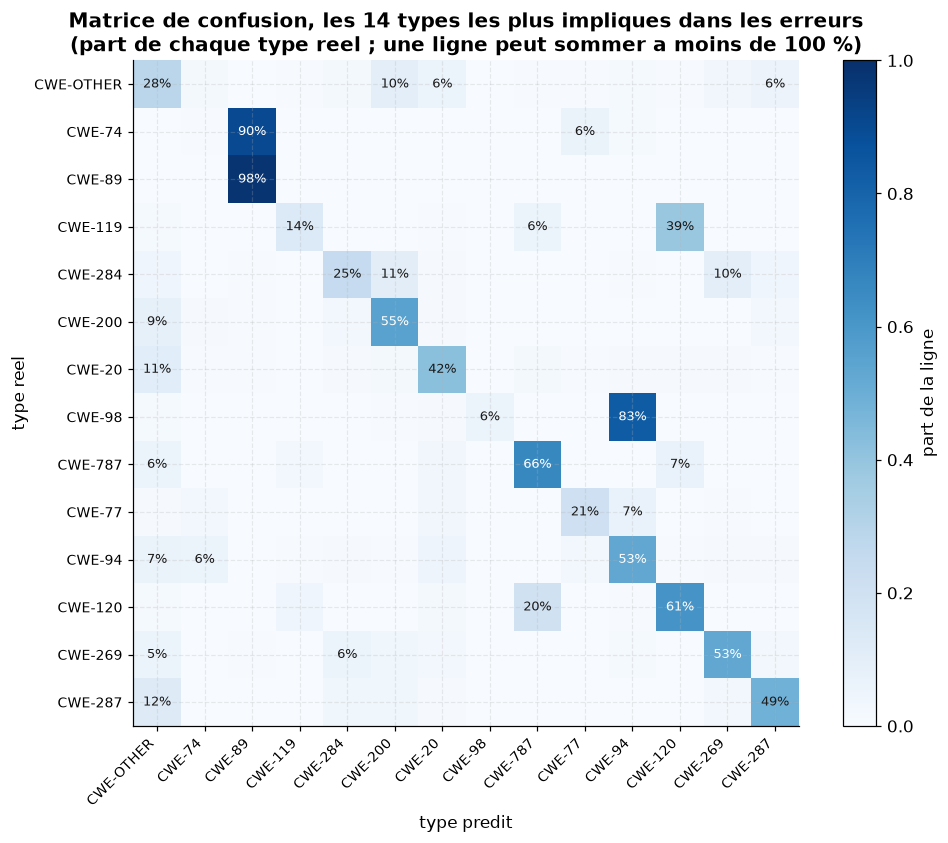

In [31]:
# A 71 classes la matrice complete est illisible : il faut en selectionner un sous-ensemble.
# On ne prend PAS simplement les types les plus frequents -- on prendrait des classes bien traitees
# et les confusions interessantes tomberaient hors du cadre. On classe les types par leur
# IMPLICATION DANS LES ERREURS (comme type reel ou comme type predit) et on garde les 14 premiers.
implication = (erreurs.vrai.value_counts()
               .add(erreurs.predit.value_counts(), fill_value=0)
               .sort_values(ascending=False))
principaux = [c for c in implication.head(14).index if c in support.index]
# Affichage par effectif decroissant : la diagonale reste lisible comme diagonale.
principaux = sorted(principaux, key=lambda c: -support.get(c, 0))
idx = {c: i for i, c in enumerate(principaux)}
N = len(principaux)

M = np.zeros((N, N))
effectif_reel = np.zeros(N)      # nombre TOTAL de CVE de chaque type, predictions hors cadre incluses

for v, p in zip(vrais, predits):
    nv = noms[str(v)]
    if nv not in idx:
        continue
    effectif_reel[idx[nv]] += 1
    np_ = noms[str(p)]
    if np_ in idx:
        M[idx[nv], idx[np_]] += 1

# On divise par l'effectif REEL du type, pas par le total tombant dans le cadre : sinon une classe
# dont les predictions partent majoritairement hors des 12 affichees verrait ses taux gonfles.
# Consequence assumee : une ligne peut sommer a MOINS de 100 %.
Mn = M / effectif_reel[:, None].clip(min=1)

fig, ax = plt.subplots(figsize=(9.4, 7.8))
im = ax.imshow(Mn, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(N)); ax.set_xticklabels(principaux, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(N)); ax.set_yticklabels(principaux, fontsize=9)
ax.set(xlabel="type predit", ylabel="type reel")
ax.set_title(f"Matrice de confusion, les {N} types les plus impliques dans les erreurs\n"
             "(part de chaque type reel ; une ligne peut sommer a moins de 100 %)")

# On inscrit les valeurs notables : la diagonale, et toute confusion depassant 5 %.
for i in range(N):
    for j in range(N):
        if Mn[i, j] >= 0.05:
            ax.text(j, i, f"{Mn[i, j]:.0%}", ha="center", va="center", fontsize=8.5,
                    color="white" if Mn[i, j] > 0.5 else "#1a1a1a")

fig.colorbar(im, ax=ax, fraction=0.045, label="part de la ligne")
plt.tight_layout()
plt.show()

**Ce que révèle la matrice.** Les erreurs ne sont pas aléatoires : elles se concentrent entre types
**sémantiquement voisins**. Les débordements mémoire se confondent entre eux, les défauts
d'autorisation entre eux.

**La conséquence limite ce que nous pouvons prétendre mesurer.** Une part de notre "taux d'erreur"
n'est pas de l'erreur de modèle : c'est du **désaccord d'annotation**. La même vulnérabilité peut
légitimement être étiquetée CWE-119 ou CWE-787 selon l'analyste et le niveau de détail qu'il retient.
Notre modèle apprend cette hésitation en même temps que la tâche, puis se la voit reprocher à
l'évaluation.

Nous n'avons pas les moyens de quantifier cette part - il faudrait un double étiquetage par des
experts dont nous ne disposions pas. Nous la signalons comme une **limite du chiffre**, pas comme
une excuse.

> **Ce constat appelle deux remèdes qu'il ne faut pas confondre**, car ils donnent des résultats
> opposés - c'est l'une des leçons les plus utiles de ce projet.
>
> *Remonter aux ancêtres au cas par cas*, en s'élevant dans l'arbre jusqu'à être assez sûr : testé,
> **réfuté** (section 8). Les réponses deviennent trop vagues, 7,2 types couverts en moyenne.
>
> *Redéfinir la cible* sur une partition grossière **fixe**, identique pour toutes les CVE : testé,
> **c'est la seule piste qui aboutit** (section 9), avec +11 points de précision et +31 de couverture.
>
> Même diagnostic, deux remèdes, deux issues contraires. Une explication convaincante d'un phénomène
> ne dit rien de ce qui le corrigera.

Regardons enfin quelques erreurs concrètes.

In [32]:
# Les erreurs les plus instructives sont celles ou le modele s'est trompe AVEC une forte confiance :
# ce sont elles qui degradent le contrat, puisqu'elles passent le seuil.
conf = z["test_conf"]
faux_surs = np.where((vrais != predits) & (conf > 0.99))[0]

# Graine fixee : les memes exemples s'affichent a chaque execution, y compris devant le jury.
rng = np.random.default_rng(0)
for i in rng.choice(faux_surs, 3, replace=False):
    print(f"vrai type   : {noms[str(vrais[i])]}")
    print(f"predit      : {noms[str(predits[i])]}   (confiance {conf[i]:.3f})")
    print(f"description : {test.text.iloc[i][:260]}...")
    print("-" * 100)

print(f"\n{milliers(len(faux_surs))} erreurs commises avec plus de 99 % de confiance, "
      f"soit {pct(len(faux_surs) / len(vrais))} du jeu de test.")

vrai type   : CWE-74
predit      : CWE-89   (confiance 0.997)
description : A vulnerability, which was classified as critical, was found in PHPGurukul Company Visitor Management System 1.0. Affected is an unknown function of the file /bwdates-reports-details.php. The manipulation of the argument fromdate/todate leads to sql injection....
----------------------------------------------------------------------------------------------------
vrai type   : CWE-74
predit      : CWE-89   (confiance 0.993)
description : A vulnerability classified as critical has been found in code-projects Patient Record Management System 1.0. Affected is an unknown function of the file /edit_xpatient.php. The manipulation of the argument lastname leads to sql injection. It is possible to lau...
----------------------------------------------------------------------------------------------------
vrai type   : CWE-OTHER
predit      : CWE-203   (confiance 0.999)
description : An observable timing discrepancy in @p

---
---
# 11 - Démonstration : le modèle en fonctionnement

Jusqu'ici nous avons lu des résultats enregistrés. Chargeons le modèle réel et faisons-le travailler.

> ⏱️ Cette cellule est la seule à charger le modèle. Comptez ~30 s.

In [33]:
# ⚠️ AVANT tout import de TensorFlow : les modeles TF de transformers sont ecrits pour Keras 2,
# alors que TF 2.16+ embarque Keras 3. Sans cette variable, la construction du modele echoue.
# Elle doit etre posee ici, car c'est a l'import que TF choisit son implementation de Keras.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"      # silence les messages d'initialisation CUDA

import tensorflow as tf
import transformers
from transformers import TFAutoModel, AutoTokenizer

# Le chargement d'un modele TF depuis des poids PyTorch emet un pave d'avertissements attendus
# (les tetes de pre-entrainement inutilisees). On les tait pour garder une sortie lisible.
transformers.logging.set_verbosity_error()

MAX_LEN = cfg["max_length"]
K       = cfg["num_classes"]

def construire_modele():
    """Reconstruit exactement l'architecture entrainee, pour y recharger les poids sauvegardes.

    La structure doit correspondre au bit pres a celle de l'entrainement : Keras recharge les poids
    par position dans le graphe, pas par nom. Une couche en trop et le chargement echoue.
    """
    backbone = TFAutoModel.from_pretrained(cfg["model_name"])
    ids  = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
    mask = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

    # On ne garde que le vecteur du jeton [CLS] (position 0) : il agrege le sens de toute la sequence.
    cls = backbone(ids, attention_mask=mask).last_hidden_state[:, 0, :]
    x   = tf.keras.layers.Dropout(0.3)(cls)
    # dtype='float32' impose : en precision mixte, le softmax deborde et la perte devient NaN.
    out = tf.keras.layers.Dense(K, activation="softmax", dtype="float32")(x)
    return tf.keras.Model([ids, mask], out)

modele = construire_modele()
modele.load_weights(cfg["checkpoint"])
tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
print(f"modele charge depuis {cfg['checkpoint']}")

I0000 00:00:1786276783.785893 3796200 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1786276784.696270 3796200 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


/home/sahlouls/repos/alyra/cwe-finetuning/.venv/lib/python3.12/site-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


modele charge depuis best_distilbert-base-uncased_finetune_71cl.weights.h5


In [34]:
SEUIL = contrat["seuil"]     # le seuil du contrat, calibre sur 2024 -- pas une valeur inventee ici

# Selection DELIBEREE, pas un tirage au hasard : on veut illustrer les trois comportements du
# systeme sous contrat. Un tirage uniforme donnerait surtout des abstentions et ne montrerait rien.
conf_s, juste_s = z["test_conf"], z["test_juste"]
rng = np.random.default_rng(7)     # graine fixe : les memes exemples a chaque execution

repond_juste = np.where((conf_s >= SEUIL) & juste_s)[0]      # au-dessus du seuil, et correct
repond_faux  = np.where((conf_s >= SEUIL) & ~juste_s)[0]     # au-dessus du seuil, et faux
sabstient    = np.where(conf_s < SEUIL)[0]                   # sous le seuil : pas de reponse

selection = [(int(rng.choice(repond_juste)), "reponse juste"),
             (int(rng.choice(repond_juste)), "reponse juste"),
             (int(rng.choice(repond_faux)),  "reponse FAUSSE  (les ~22 % d'erreurs du contrat)"),
             (int(rng.choice(sabstient)),    "abstention      (confiance sous le seuil)")]

# Une seule passe d'inference sur les quatre descriptions retenues.
textes = [test.text.iloc[i] for i, _ in selection]
enc = tokenizer(textes, truncation=True,
                padding="max_length",     # ⚠️ PAS padding=True : le modele attend une forme FIXE
                max_length=MAX_LEN, return_tensors="tf")
proba = modele([enc["input_ids"], enc["attention_mask"]], training=False).numpy()

print(f"seuil du contrat : {SEUIL:.4f}\n" + "=" * 104)
for (i, attendu), p in zip(selection, proba):
    meilleurs = np.argsort(p)[::-1][:3]
    verite    = noms[str(test.label.iloc[i])]
    repond    = p[meilleurs[0]] >= SEUIL

    print(f"\n[{attendu}]")
    print(f"  {test.text.iloc[i][:190]}...")
    print(f"  vrai type : {verite}")
    if repond:
        pred = noms[str(meilleurs[0])]
        print(f"  -> REPOND  {pred:<12} {'✔ correct' if pred == verite else '✘ faux'}")
    else:
        print(f"  -> S'ABSTIENT (aucune hypothese au-dessus du seuil)")
    for r in meilleurs:
        print(f"       {noms[str(r)]:<12} {p[r]:7.2%}")

seuil du contrat : 0.9740

[reponse juste]
  An issue pertaining to CWE-352: Cross-Site Request Forgery was discovered in Sunbird-Ed SunbirdEd-portal v1.13.4....
  vrai type : CWE-352
  -> REPOND  CWE-352      ✔ correct
       CWE-352       99.96%
       CWE-OTHER      0.01%
       CWE-918        0.01%

[reponse juste]
  Missing Authorization vulnerability in Mahmudul Hasan Arif Enhanced Blocks – Page Builder Blocks for Gutenberg enhanced-blocks allows Exploiting Incorrectly Configured Access Control Securit...
  vrai type : CWE-862
  -> REPOND  CWE-862      ✔ correct
       CWE-862       99.98%
       CWE-306        0.01%
       CWE-434        0.00%

[reponse FAUSSE  (les ~22 % d'erreurs du contrat)]
  A discrepancy in the error message returned by the login function of Reolink Smart 2K+ Plug-in Wi-Fi Video Doorbell with Chime - firmware v3.0.0.4662_2503122283 when entering the wrong usern...
  vrai type : CWE-284
  -> REPOND  CWE-209      ✘ faux
       CWE-209       98.25%
       CWE

## Une objection que vous avez peut-être vue venir

Le premier exemple contient littéralement la chaîne **"CWE-352"** dans sa description. Le modèle
n'a pas eu grand-chose à deviner - il a lu la réponse. D'où la confiance de 99,96 %.

C'est une fuite. La question honnête est : **combien de nos résultats en dépendent ?** Mesurons-le
plutôt que de l'écarter.

In [35]:
import re

# Une description qui cite son propre identifiant CWE rend la tache triviale. On compte ces cas
# et surtout on mesure ce que devient le resultat SANS eux.
vrais_noms = np.array([noms[str(i)] for i in test.label])

cite_un_cwe = test.text.str.contains(r"CWE-\d+", case=False, regex=True).values
cite_le_sien = np.array([
    bool(re.search(rf"\b{re.escape(v)}\b", t, re.I)) if v != "CWE-OTHER" else False
    for v, t in zip(vrais_noms, test.text)])

juste_s = z["test_juste"]

print(f"CVE de test                                     : {milliers(len(test))}")
print(f"  citant un identifiant 'CWE-xxx' quelconque    : {milliers(cite_un_cwe.sum())}  "
      f"({pct(cite_un_cwe.mean(), 2)})")
print(f"  citant LEUR PROPRE identifiant                : {milliers(cite_le_sien.sum())}  "
      f"({pct(cite_le_sien.mean(), 2)})")
print()
print(f"reussite sur ces CVE ou la reponse est ecrite   : {pct(juste_s[cite_le_sien].mean())}")
print(f"reussite sur toutes les autres                  : {pct(juste_s[~cite_le_sien].mean())}")
print()
print(f"resultat global tel qu'annonce                  : {pct(juste_s.mean())}")
print(f"resultat en retirant les CVE concernees         : {pct(juste_s[~cite_le_sien].mean())}")
print(f"-> impact sur nos conclusions                   : "
      f"{pct(juste_s.mean() - juste_s[~cite_le_sien].mean(), 2)}")

CVE de test                                     : 43 229
  citant un identifiant 'CWE-xxx' quelconque    : 357  (0,83 %)
  citant LEUR PROPRE identifiant                : 243  (0,56 %)

reussite sur ces CVE ou la reponse est ecrite   : 95,1 %
reussite sur toutes les autres                  : 55,1 %

resultat global tel qu'annonce                  : 55,4 %
resultat en retirant les CVE concernees         : 55,1 %
-> impact sur nos conclusions                   : 0,22 %


**Verdict : la fuite existe mais elle est négligeable.** Elle concerne un peu plus d'une CVE sur
deux cents, et la retirer déplace le résultat de deux dixièmes de point - bien en dessous du bruit
entre deux exécutions du même entraînement.

Nos conclusions ne reposent donc pas dessus. Nous préférons l'avoir mesuré et le dire, plutôt que
de laisser la question ouverte : sur un jeu de données où la fuite aurait été à 20 % au lieu de
0,6 %, l'ensemble des chiffres de ce notebook aurait été à refaire.

---
---
# 12 - Conclusion

## Ce qui a été fait

Un classifieur CVE -> CWE par **fine-tuning** de DistilBERT sur 71 types de vulnérabilités, évalué
selon un protocole temporel strict, puis mesuré sur un **contrat de service** réaliste.

L'ablation demandée par le sujet est concluante : le fine-tuning complet domine largement
l'extraction de caractéristiques, parce que la tâche demande des distinctions que le pré-entraînement
généraliste n'avait aucune raison de développer.

## Le résultat technique

| | |
|---|---|
| macro-F1 (test 2025, 71 classes) | **0,467** - contre 0,424 pour TF-IDF + régression logistique |
| **Contrat pour la remédiation** (CWE précis) | **81,5 % de précision sur 57,9 % des CVE** (~ 25 000/an, dont 20 400 justes) |
| **Contrat pour le tri et le reporting** (famille) | **89,2 % de précision sur 86,6 % des CVE** (~ 37 400/an) |
| Pistes d'amélioration testées | **12 - dix sans gain, une modeste, une décisive** |

> **Les deux contrats ne servent pas à la même chose, et il ne faut pas les confondre.** MITRE
> attache ses mitigations aux CWE précis : 81 % des `Variant` portent un texte de remédiation,
> contre 30 % des `Pillar` et **aucune** des 422 catégories. Un type de faille au niveau famille
> permet de trier et de rendre compte ; il ne désigne aucun correctif. **Le chiffre de la chaîne
> vers la remédiation est donc celui du CWE précis - 81,5 % / 57,9 % pour le modèle déployé (218k),
> 78,3 % / 55,3 % pour la configuration de référence des ablations (40k) - pas le 89 % de la famille.**
>
> **Avec une réserve que nous ne masquons pas** : si l'on exige une *stratégie nommée* dans le
> vocabulaire fermé de MITRE - le seul niveau qu'un contrôle automatisé sache vérifier - la
> couverture tombe à 19-33 % **quel que soit le niveau**, sans gradient. Le CWE précis permet de
> *choisir* une remédiation ; il ne suffit pas à la *vérifier*. Aucune finesse de prédiction ne
> corrige ça - c'est une limite de la documentation, pas du modèle.

## Le résultat méthodologique, qui compte davantage

> **L'exactitude en laboratoire peut prédire la valeur en production à l'envers.**

Notre meilleure configuration au sens classique - 97 % d'exactitude sur 10 classes - est la pire une
fois branchée sur la population réelle. La cause est structurelle : un softmax ne peut pas
s'abstenir, il attribue donc un type à des CVE dont le vrai type n'existe pas dans son périmètre.

Une fois ce diagnostic posé, onze pistes d'amélioration ont été testées. **Une seule aide
nettement** - cinq fois plus de données, environ 1 700 CVE justes de plus par an - et encore
avons-nous d'abord conclu l'inverse, en la mesurant avec le protocole fuité que nous venions de
dénoncer (section 8). Les autres échangent de la précision contre de la couverture sans rien
gagner.

**La douzième a réussi - et elle ne touche pas au modèle.** Elle change la cible : prédire la
famille MITRE plutôt que le CWE précis fait monter simultanément la précision de **11 points** et la
couverture de **31**. Le mécanisme est direct : la partition en familles recouvre l'espace entier, donc
le hors-périmètre - la cause identifiée plus haut - **disparaît par construction** (15,5 % -> 0,3 %).

Mais cette réussite s'accompagne d'une correction que nous devons à l'honnêteté : **l'hypothèse qui
avait motivé le test était fausse**. Nous pensions qu'une famille suffirait à choisir un contrôle
compensatoire. MITRE dit le contraire - ses mitigations sont attachées aux CWE précis. Le gain est
donc réel pour le **tri**, nul pour la **remédiation**.

D'où la leçon, qui est la même que celle de la section 6 appliquée un cran plus haut :

> **Nous optimisions d'abord la mauvaise métrique, puis la mauvaise cible.**
> Les deux fois, l'erreur n'était pas technique - c'était d'avoir accepté la définition du problème
> sans la confronter à l'usage.

## Les limites, énoncées franchement

**L'étiquetage de référence est bruité, et nous l'avons mesuré indirectement.** **51 % de nos
erreurs** se produisent entre types parent et enfant de la taxonomie MITRE - contre 3 % attendus si
le modèle se trompait au hasard - et seulement **0,5 % sans aucun lien taxonomique**, contre 14 % au
hasard. Le modèle hésite sur le niveau de détail, presque jamais sur la nature de la faille. Une
part de notre taux d'erreur est donc du désaccord d'annotation, pas de l'erreur. Nous n'avons pas
pu isoler cette part faute d'un double étiquetage expert, et nous n'avons revendiqué aucun crédit
dessus - mais elle n'est pas négligeable.

**Le bruit d'étiquetage, confirmé par une seconde voie totalement indépendante.** Nous avons
interrogé l'historique de modifications du NVD sur un échantillon de CVE de 2025. **18,6 % voient
leur CWE révisé après publication, et un tiers de ces révisions change de famille** - CWE-284 -> CWE-434,
CWE-476 -> CWE-826. Deux méthodes sans rapport l'une avec l'autre concluent que la vérité terrain
est instable.

**Une seule graine aléatoire par configuration - et nous avons mesuré ce que ça coûte.** La
section 9 le montre crûment : le même comparatif change de signe selon le budget d'entraînement,
avec une amplitude quatre fois supérieure à nos intervalles de confiance. Ces intervalles bornaient
la variance du **tirage de test** alors que la variance dominante était celle de l'**entraînement**.
Des moyennes sur plusieurs graines n'auraient pas été un raffinement : elles étaient nécessaires
pour tout écart inférieur à quelques pour cent.

**La transportabilité - la limite la plus importante pour qui voudrait réutiliser ce modèle.**
Le contrat vaut pour des descriptions de **type NVD** (304 caractères médians). La seule population
où il n'existe aujourd'hui **aucun typage** est celle des findings qui ne viennent pas d'une CVE :
résultats SAST/DAST, défauts de configuration, règles propriétaires de scanners. Ils n'ont ni CWE
ni NVD dont hériter, et ils sont bien plus nombreux qu'les CVE non étiquetées dans une plateforme
de gestion des vulnérabilités.

**Nous avons cherché à savoir si le modèle y survivrait, et notre première réponse était fausse.**
Une mesure par tranche de longueur sur les CVE réelles suggérait un effondrement de la couverture -
mais elle est **confondue** : la longueur sélectionne un publieur autant qu'une difficulté. Une
seconde mesure, par troncature des mêmes descriptions, semblait confirmer. Elle était **mal
spécifiée** : tronquer depuis le début supprime le terme de type dans 83 % des cas, ce qui mesure
l'absence d'information, pas sa concision.

Le bon test isole la **densité** : une fenêtre de 60 caractères prise *autour* du terme de type -
soit exactement le profil d'un finding de scanner, qui mène par le type.

| Sur les mêmes CVE | Longueur | Couverture | Précision |
|---|---|---|---|
| Texte complet | 653 car. | 98,7 % | 97,9 % |
| Tronqué depuis le début | 60 car. | 68,7 % | 82,5 % |
| **Fenêtre autour du type** | **58 car.** | **98,5 %** | **97,4 %** |

> **La longueur n'est pas le problème : la densité l'est.** Un texte de 58 caractères qui énonce le
> type donne le même résultat qu'une description de 653. Le modèle encaisse le format court.

**Ce qu'il faut donc mesurer en premier sur des findings réels n'est pas la couverture, mais la
correspondance de vocabulaire.** Le risque n'est pas que le texte soit court - c'est qu'un scanner
dise "Missing X-Frame-Options header" là où le modèle n'a appris que "Improper Neutralization of
Input During Web Page Generation". Un problème de lexique, pas de format.

*Deux réserves à porter avec ce résultat* : la fenêtre contient les formulations **exactes** du NVD,
celles sur lesquelles le modèle a été entraîné ; et les 50 % de CVE au type explicite sont les plus
faciles, d'où une référence à 98,7 % contre 89,3 % sur l'ensemble.

**La dérive de description : bornée, mais pas testée là où ça compterait.** 15 % des CVE voient leur
texte modifié après publication. Sur les 17 cas observés, la prédiction du modèle est **identique
dans 17 cas sur 17** (borne haute à 95 % : 16,2 %, soit un effet plafonné à ~2,4 % des CVE). **Mais
ces 17 cas sont tous des retouches modérées** - similarité minimale 0,775, aucun cas sous 0,60. Le
cas d'une description squelettique substantiellement réécrite ensuite **n'est pas testé** : notre
échantillon n'en contient aucun. C'est "non testé", pas "réfuté".

**Une réserve qui joue contre nos propres conclusions.** Depuis 2024 le NVD diffère massivement son
analyse - 17 019 CVE de 2025 en statut `Deferred` dans nos données. Moins d'analyses NVD signifie
moins de révisions de CWE **et** moins d'enrichissements de description observés. Les deux mesures
ci-dessus sous-estiment donc probablement ce qu'elles vaudraient avec un NVD à jour.

**Le protocole qui manque, et il est réalisable.** La mesure vraiment décisive serait de prédire à
partir de la description telle qu'elle existait **à la publication**, puis de comparer au CWE
finalement retenu. L'API `cvehistory/2.0` du NVD fournit les deux - nous l'avons vérifiée et
utilisée pour les mesures ci-dessus. Nous ne l'avons pas menée à l'échelle du jeu de test complet :
c'est une collecte de plusieurs heures, pas une re-mesure.

## Ce que nous referions autrement

**Deux choses, et elles se ressemblent.**

**Définir le contrat de service avant d'entraîner.** Nous avons passé la première moitié du projet à
optimiser une métrique qui, nous le savons maintenant, ne mesurait pas ce qui compte. Toutes les
décisions prises pendant cette phase ont dû être réexaminées.

**Choisir la granularité de la cible à partir de l'action aval, pas de la taxonomie.** Nous avons
retenu 71 classes parce que c'est ce que les données offraient, jamais parce que quelqu'un en avait
besoin. La douzième piste montre le coût de ce choix par défaut : à granularité famille, le même
modèle est meilleur sur les deux axes à la fois. Onze tentatives d'amélioration technique n'ont rien
donné ; une seule question sur la définition du problème a tout débloqué.

C'est, de loin, l'enseignement le plus transférable de ce travail : **avant d'optimiser une réponse,
vérifier qu'on pose la bonne question.**

---

*Le code d'entraînement complet, exécuté sur GPU avec ses sorties, se trouve dans
`07_cwe_finetuning.ipynb`. Le rapport détaillé est dans `RAPPORT.md`.*